# Equipo 1 - Fase 1

## Import libraries

In [127]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from google.colab import files

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load dataset from GitHub

In [109]:
df = pd.read_csv('https://raw.githubusercontent.com/Pakohp88/Equipo1_mlops/main/data/raw/turkis_music_emotion_original.csv')

In [110]:
df.head()

,Class,_RMSenergy_Mean,_Lowenergy_Mean,_Fluctuation_Mean,_Tempo_Mean,_MFCC_Mean_1,_MFCC_Mean_2,_MFCC_Mean_3,_MFCC_Mean_4,_MFCC_Mean_5,...,_Chromagram_Mean_9,_Chromagram_Mean_10,_Chromagram_Mean_11,_Chromagram_Mean_12,_HarmonicChangeDetectionFunction_Mean,_HarmonicChangeDetectionFunction_Std,_HarmonicChangeDetectionFunction_Slope,_HarmonicChangeDetectionFunction_PeriodFreq,_HarmonicChangeDetectionFunction_PeriodAmp,_HarmonicChangeDetectionFunction_PeriodEntropy
0,relax,0.052,0.591,9.136,130.043,3.997,0.363,0.887,0.078,0.221,...,0.426,1.000,0.008,0.101,0.316,0.261,0.018,1.035,0.593,0.970
1,relax,0.125,0.439,6.680,142.240,4.058,0.516,0.785,0.397,0.556,...,0.002,1.000,0.000,0.984,0.285,0.211,-0.082,3.364,0.702,0.967
2,relax,0.046,0.639,10.578,188.154,2.775,0.903,0.502,0.329,0.287,...,0.184,0.746,0.016,1.000,0.413,0.299,0.134,1.682,0.692,0.963
3,relax,0.135,0.603,10.442,65.991,2.841,1.552,0.612,0.351,0.011,...,0.038,1.000,0.161,0.757,0.422,0.265,0.042,0.354,0.743,0.968
4,relax,0.066,0.591,9.769,88.890,3.217,0.228,0.814,0.096,0.434,...,0.004,0.404,1.000,0.001,0.345,0.261,0.089,0.748,0.674,0.957


# **Data cleaning**

## Detect null values

In [111]:
df.isnull().sum()

,0
Class,0
_RMSenergy_Mean,0
_Lowenergy_Mean,0
_Fluctuation_Mean,0
_Tempo_Mean,0
_MFCC_Mean_1,0
_MFCC_Mean_2,0
_MFCC_Mean_3,0
_MFCC_Mean_4,0
_MFCC_Mean_5,0


## Detect duplicates

In [112]:
df.duplicated().sum()

np.int64(12)

## Remove duplicates

In [113]:
df.drop_duplicates(inplace=True)

In [114]:
df.duplicated().sum()

np.int64(0)

## Detect outliers (Visually)


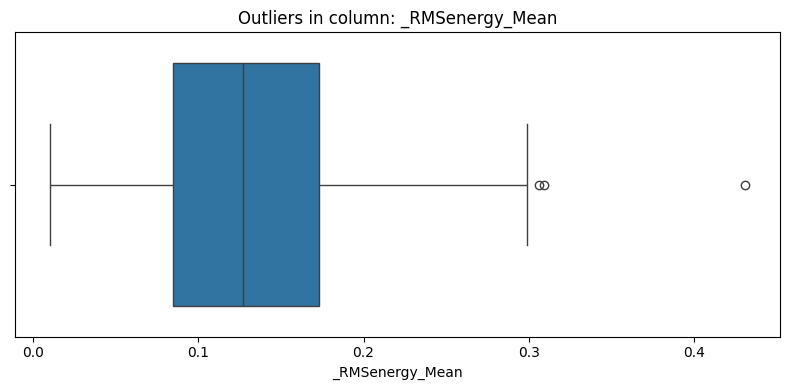

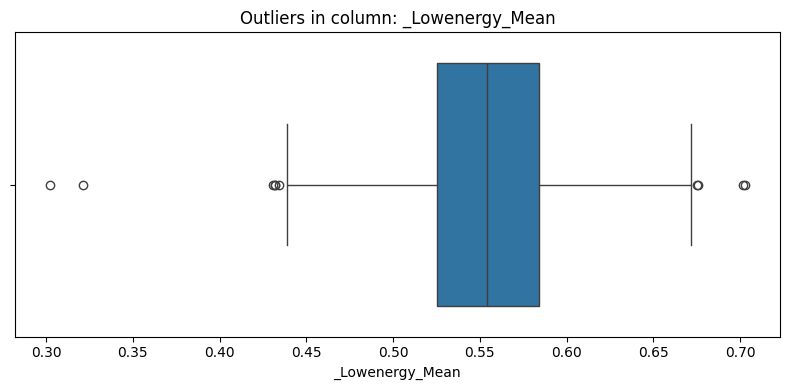

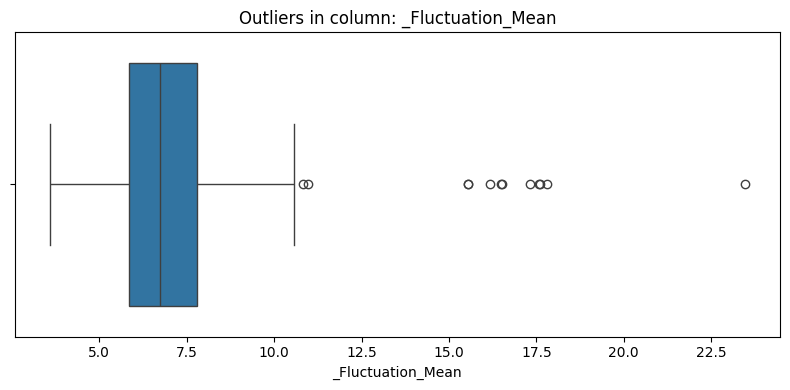

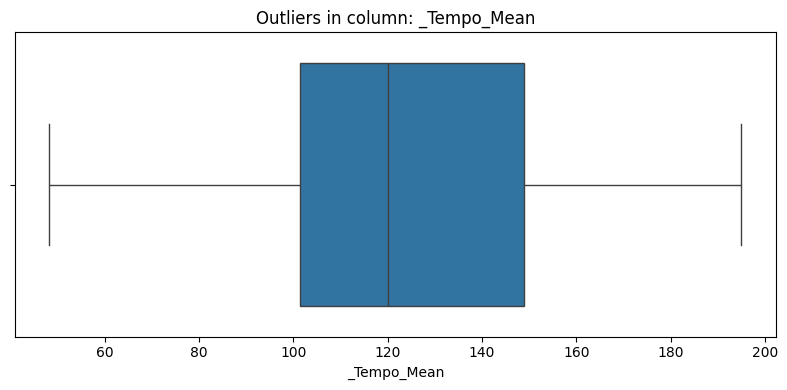

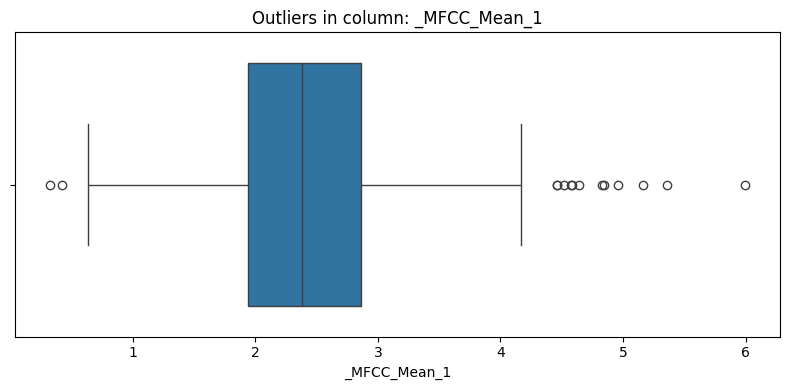

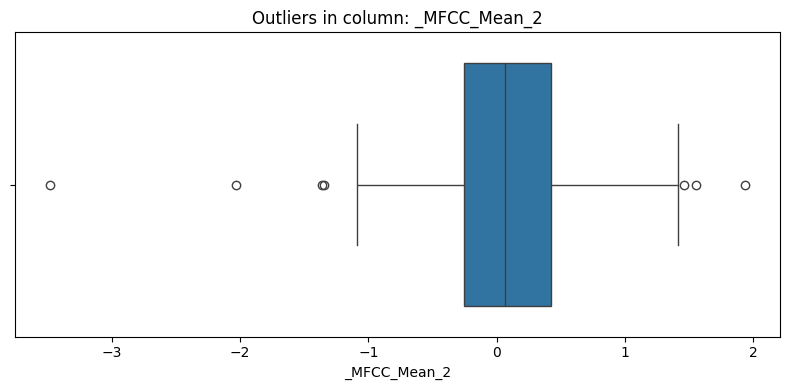

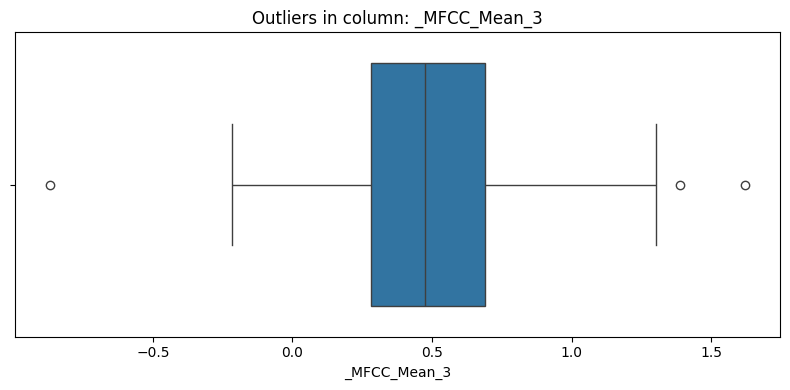

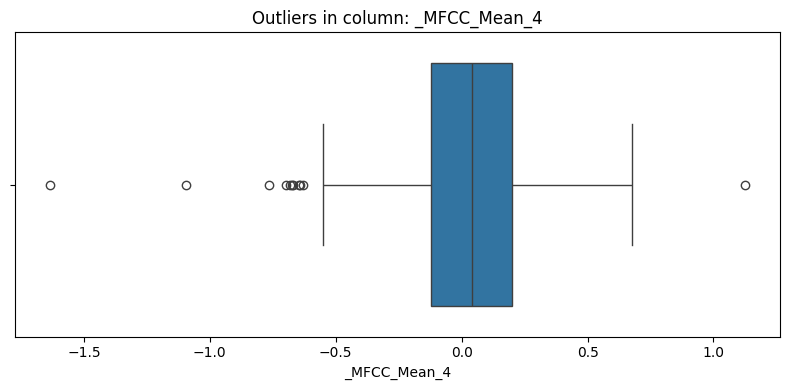

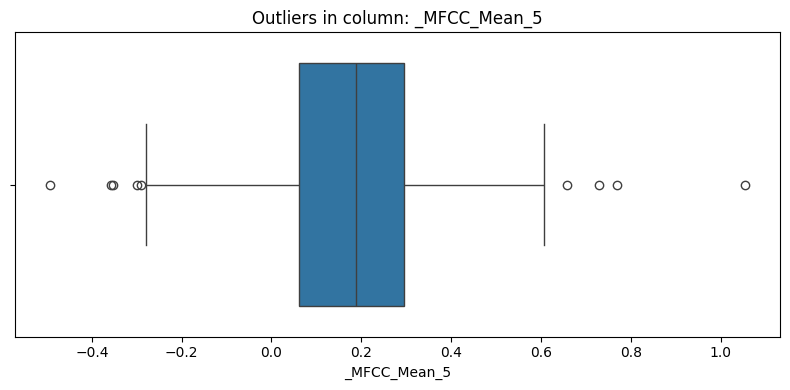

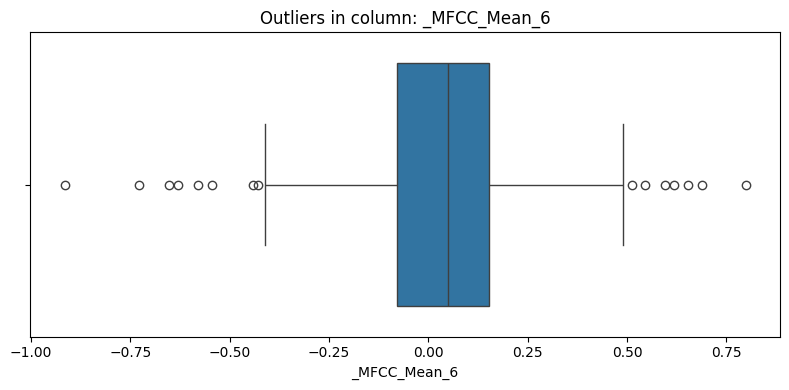

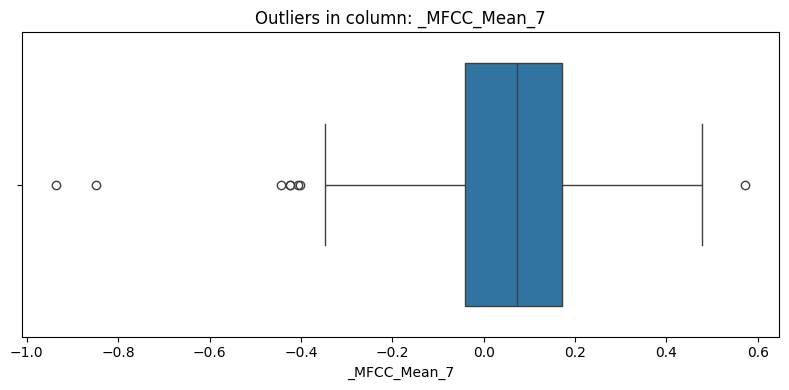

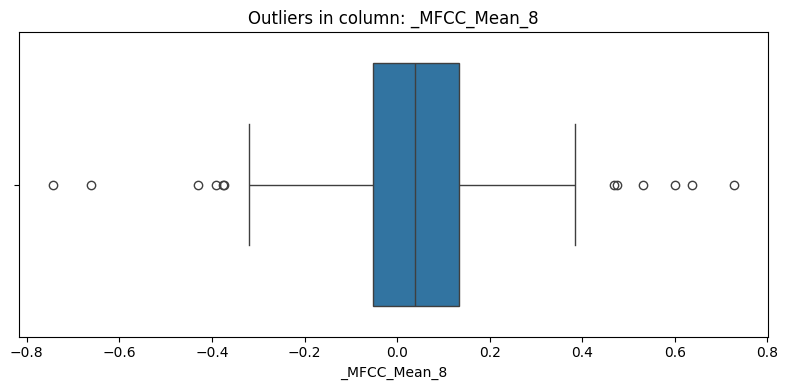

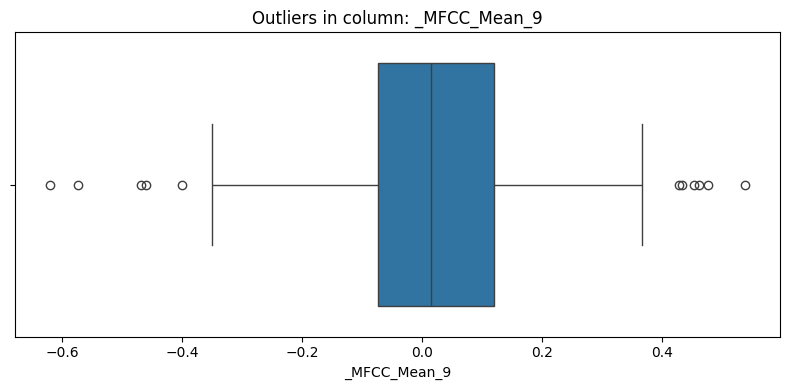

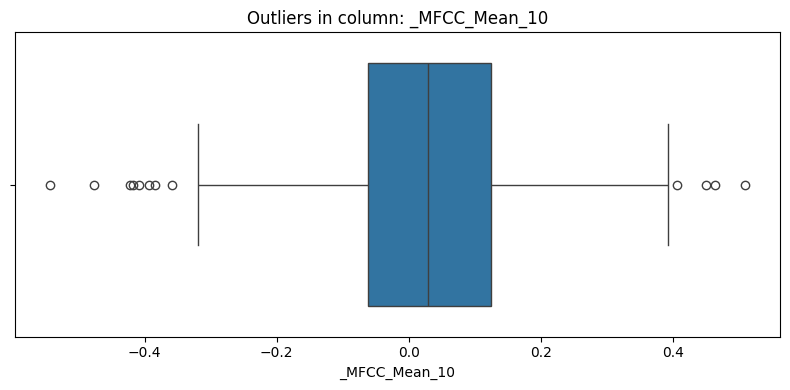

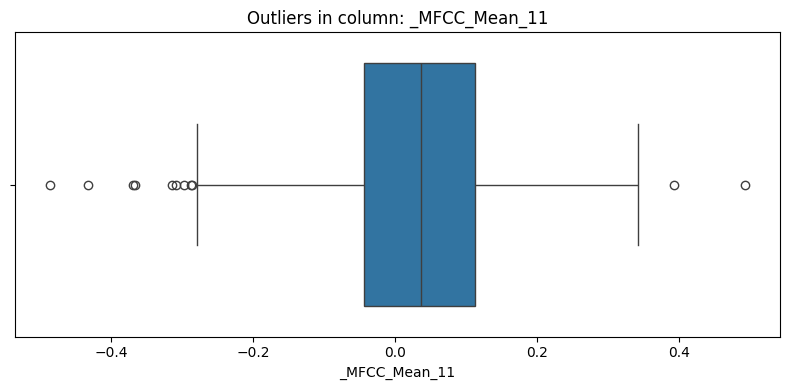

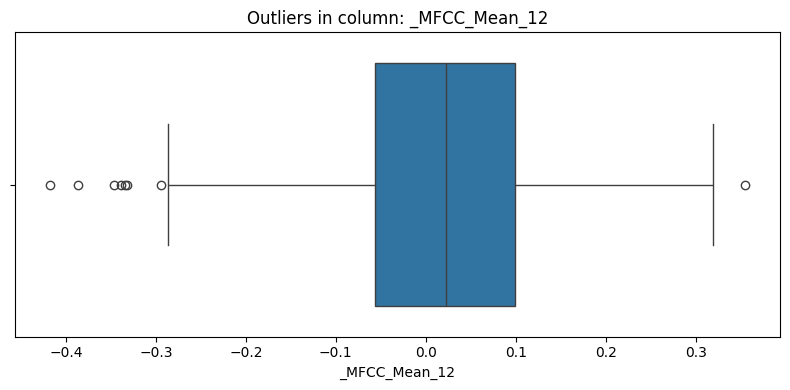

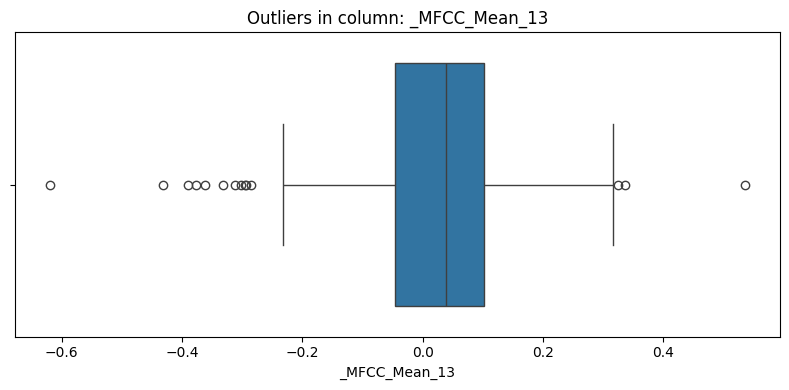

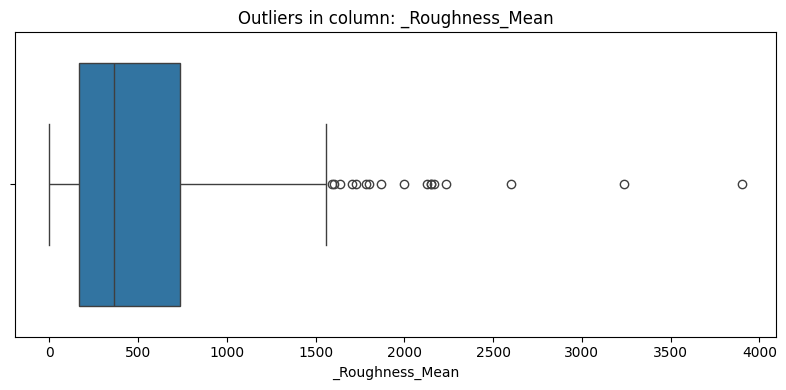

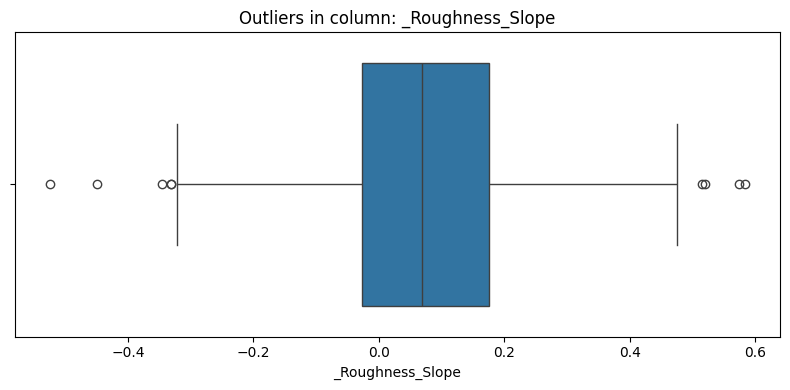

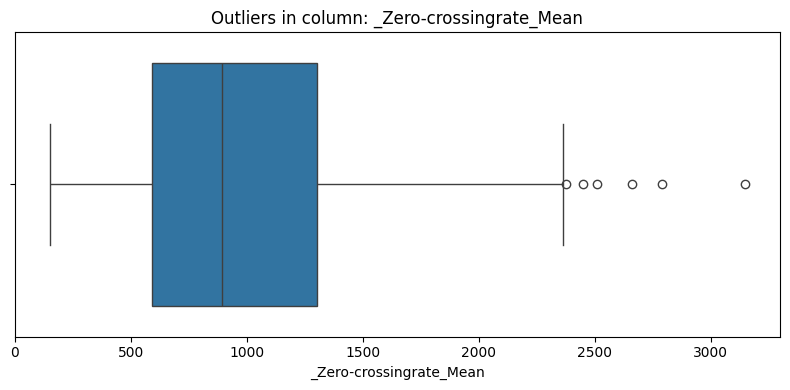

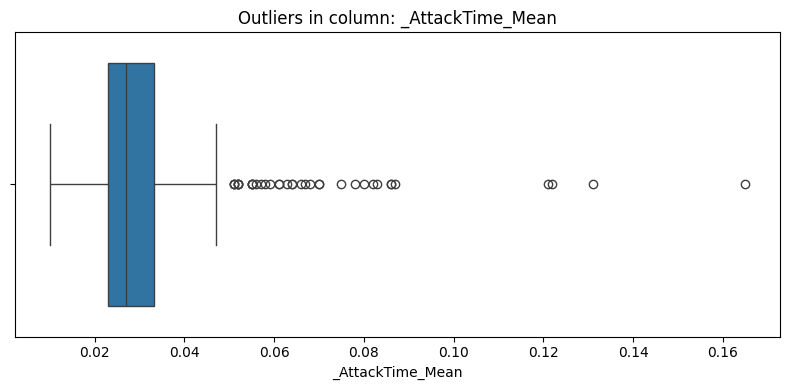

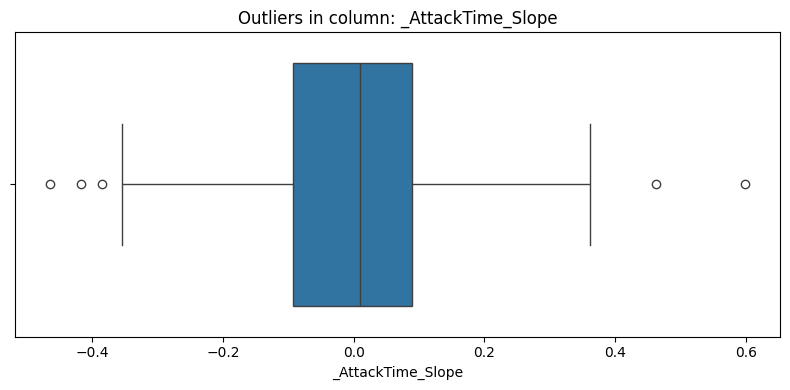

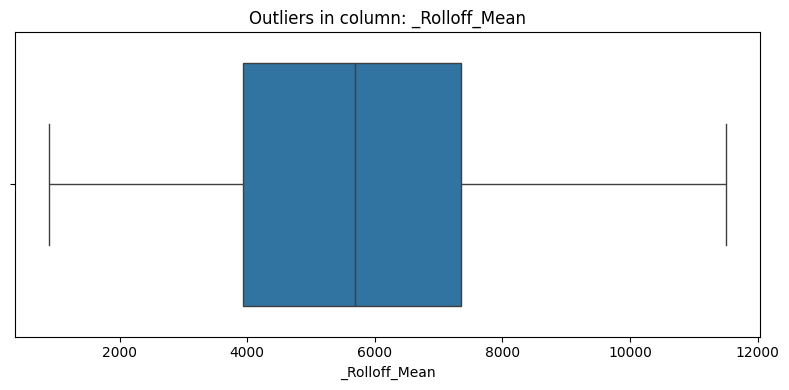

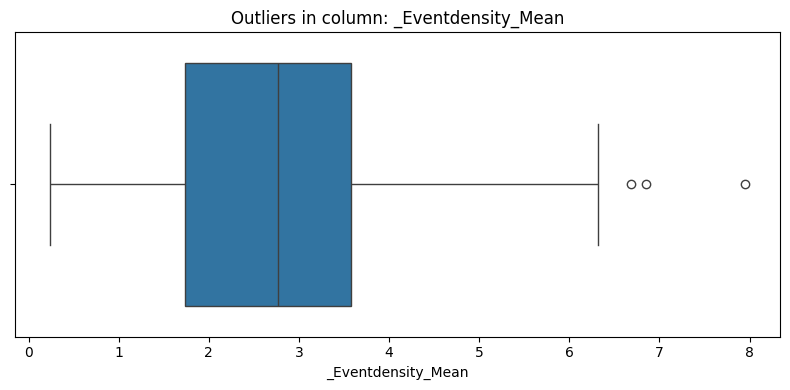

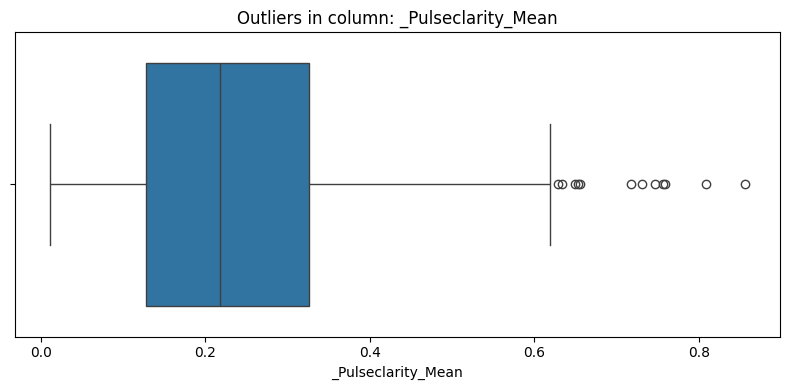

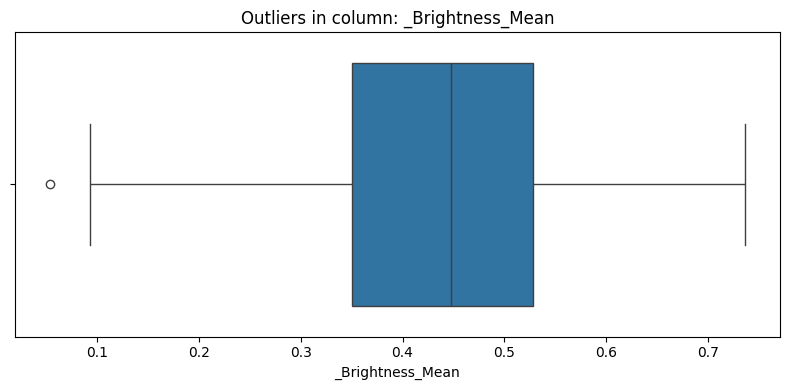

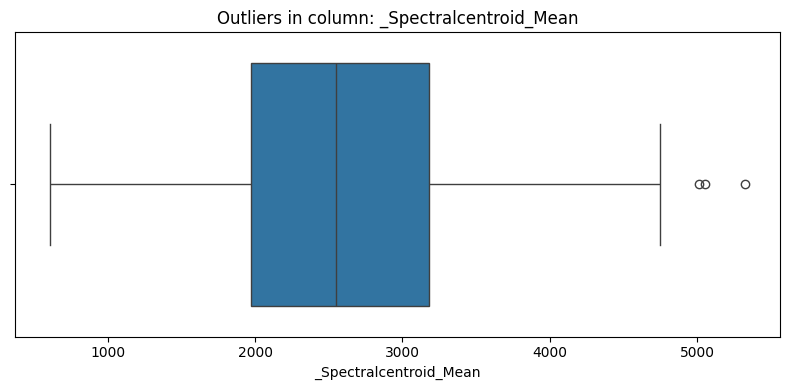

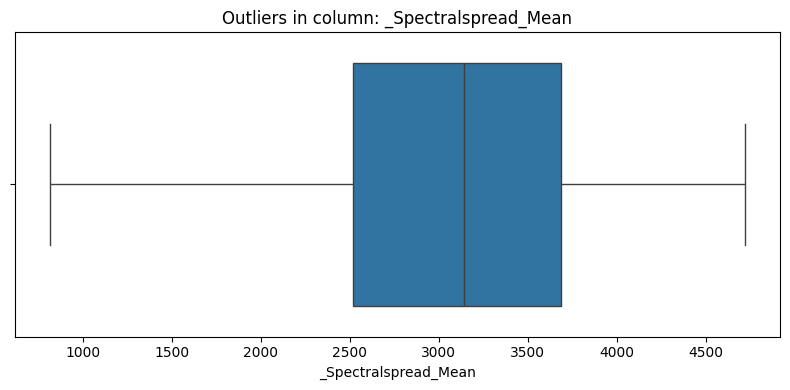

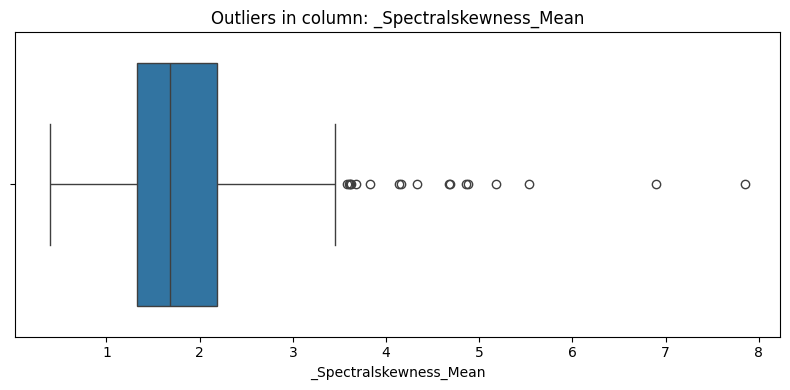

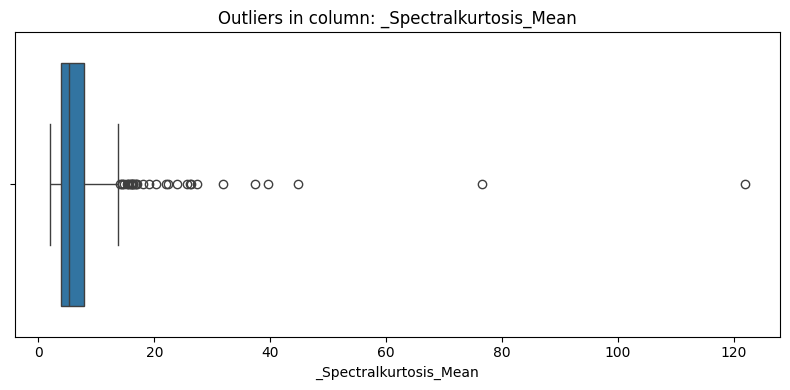

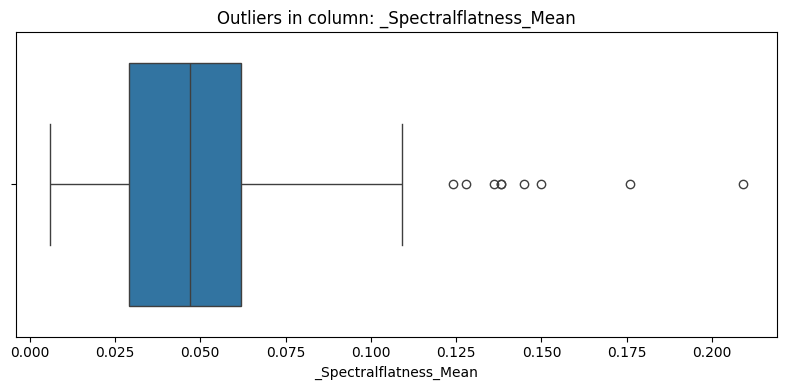

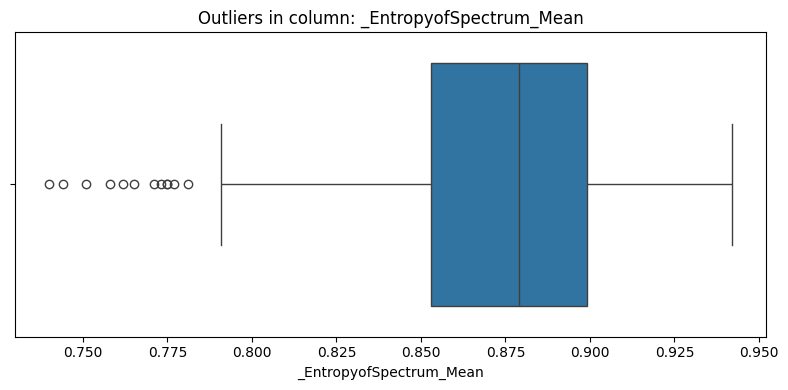

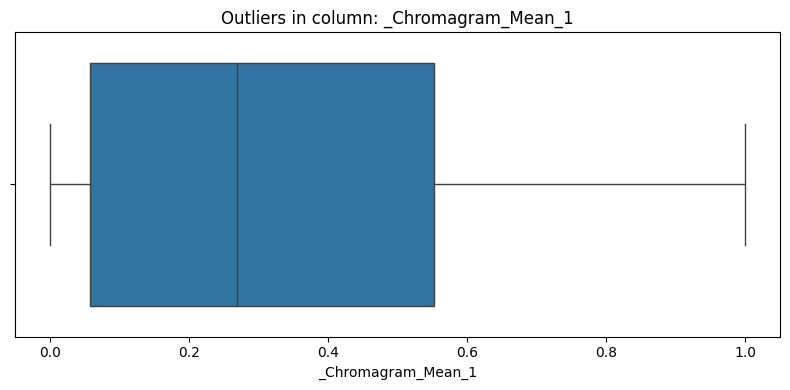

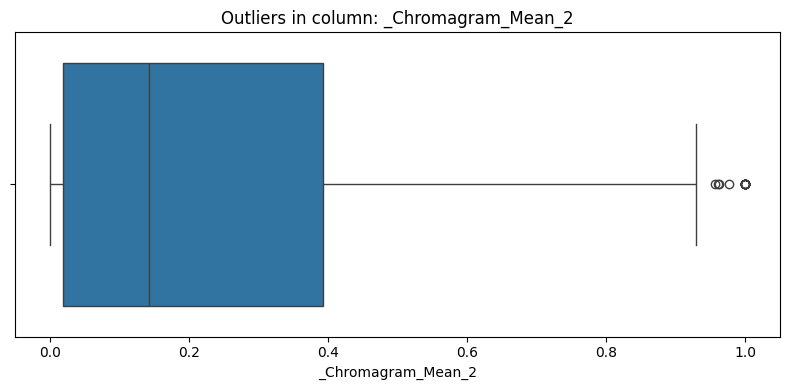

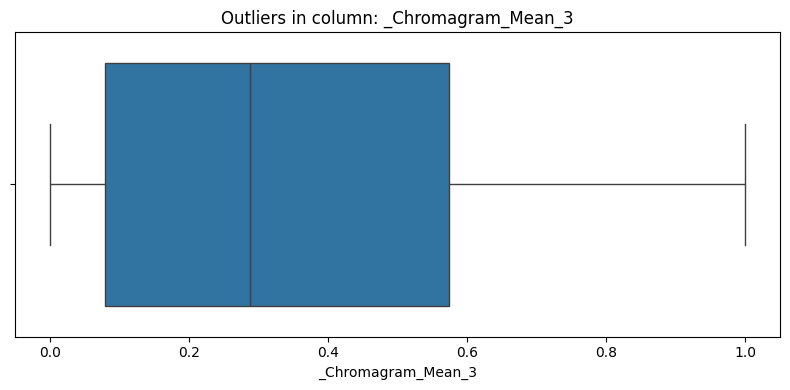

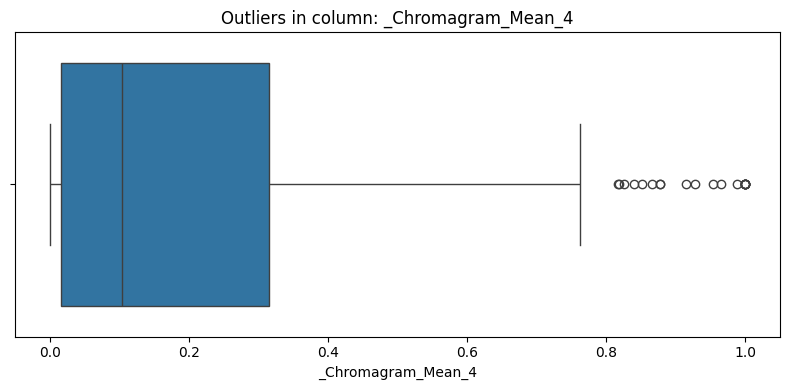

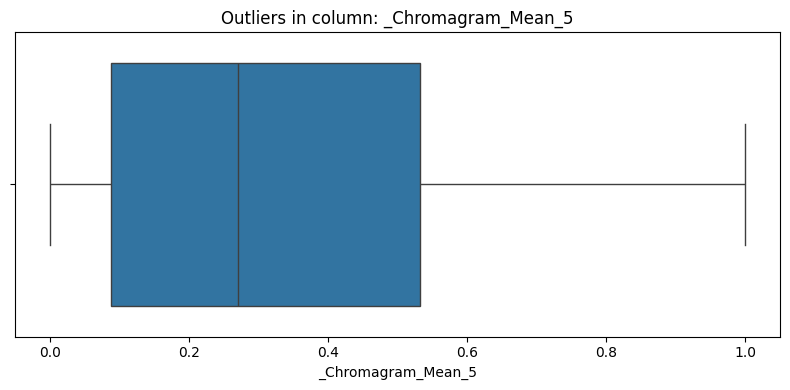

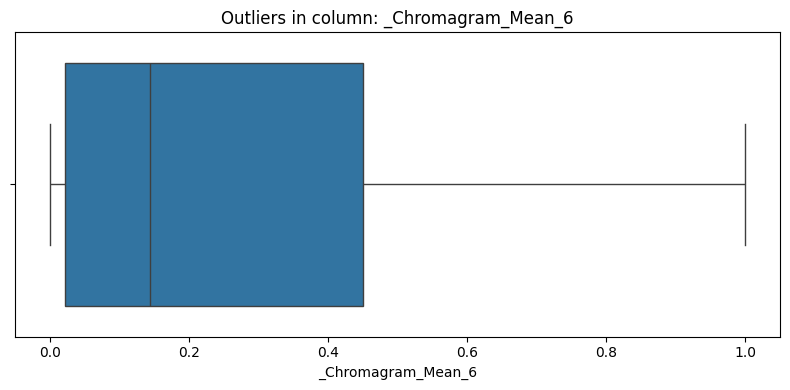

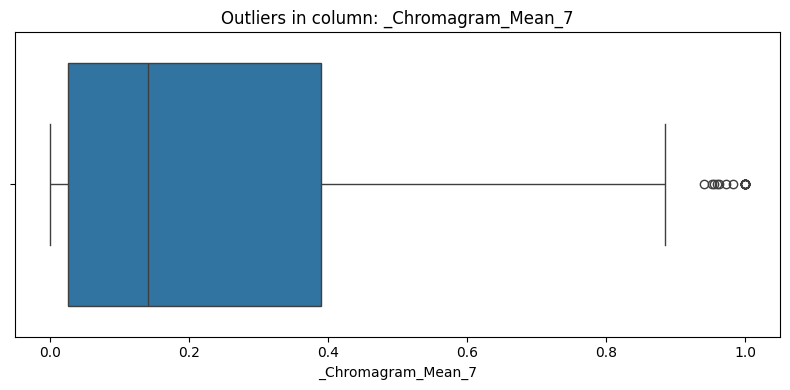

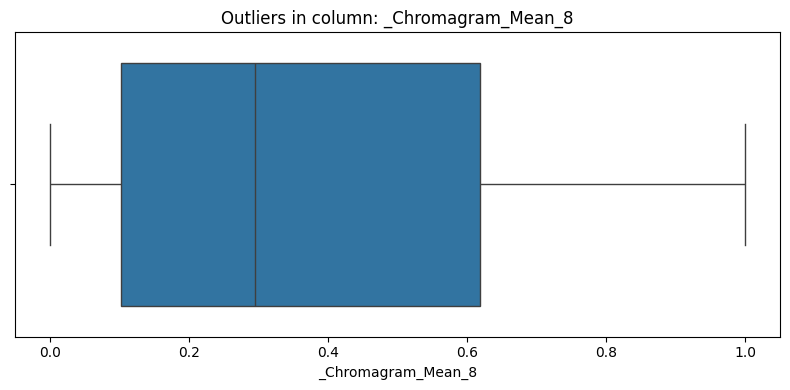

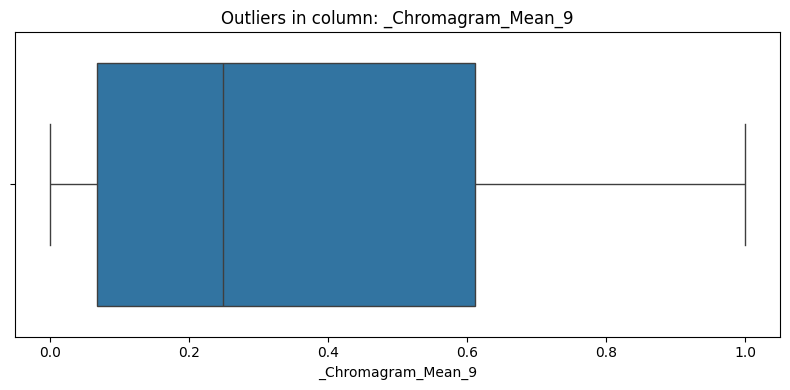

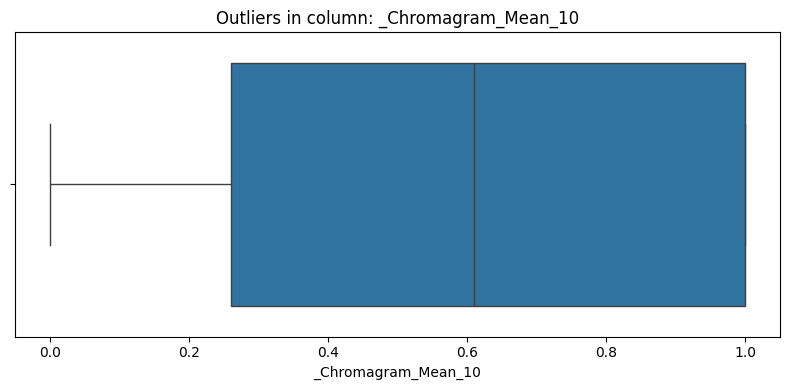

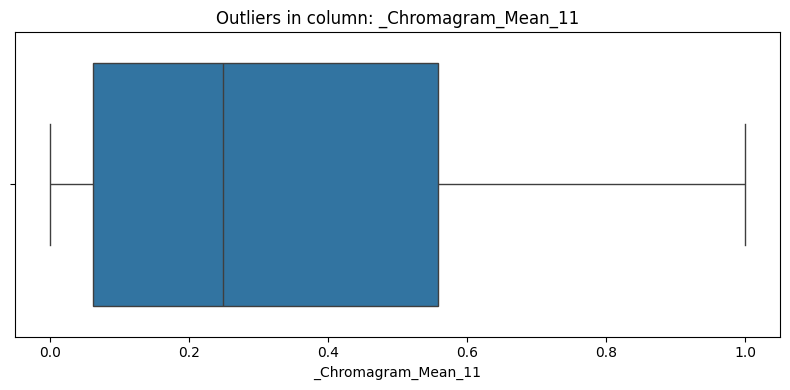

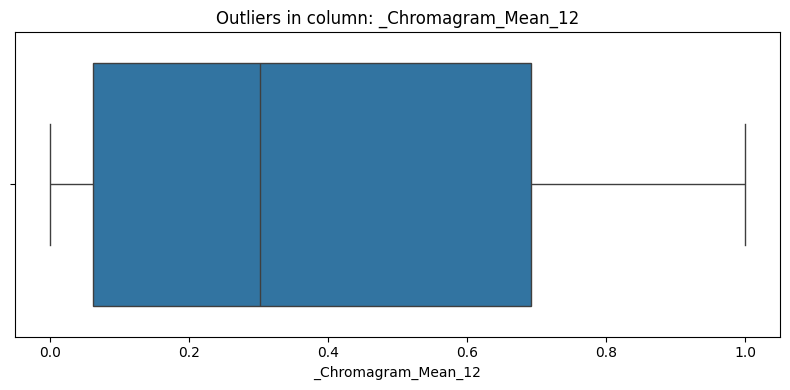

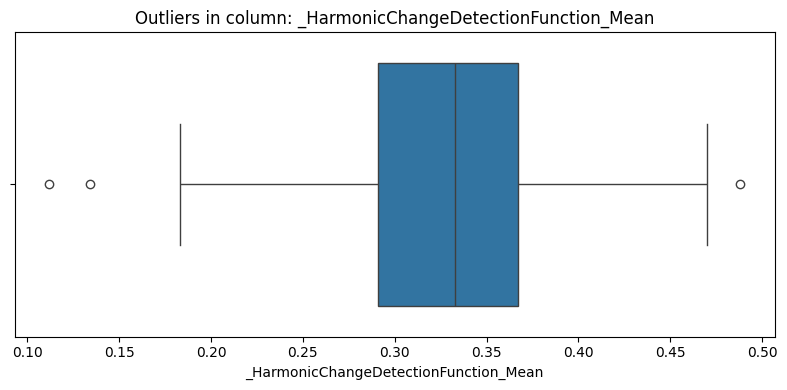

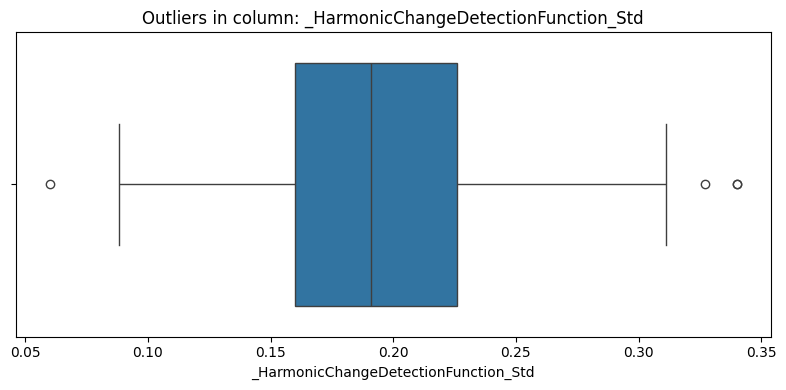

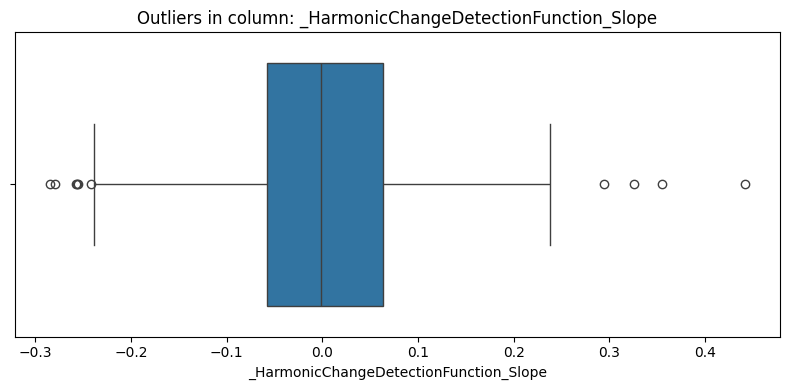

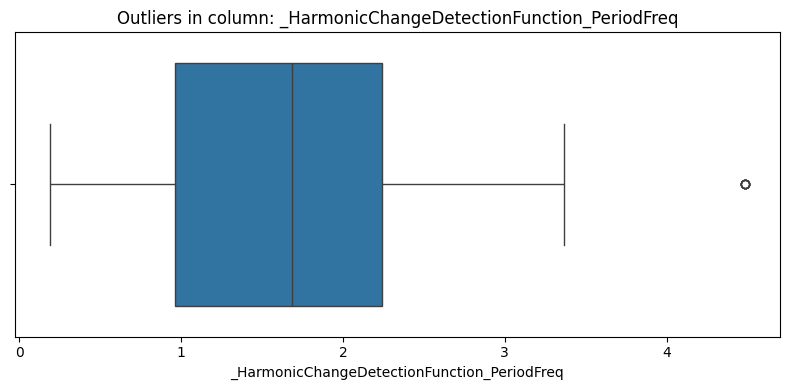

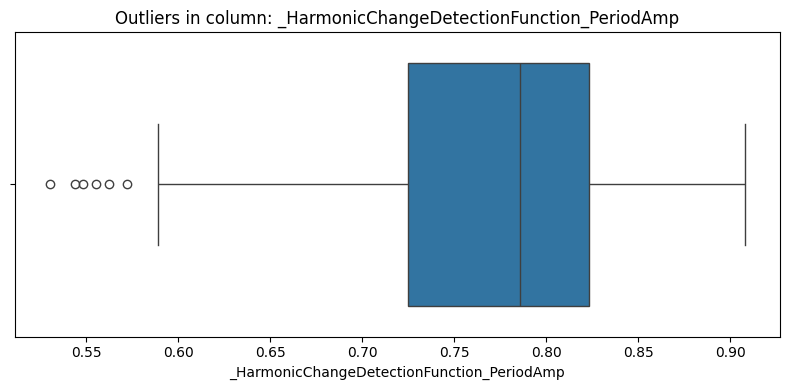

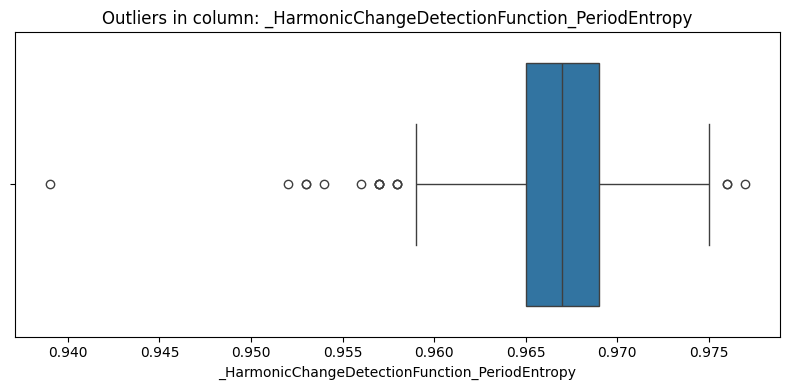

In [115]:
numeric_columns = df.select_dtypes(include='number').columns


for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in column: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## Remove outliers

In [116]:
for col in numeric_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  df = df[~((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR)))]

## Validate outliers visually after the removal process

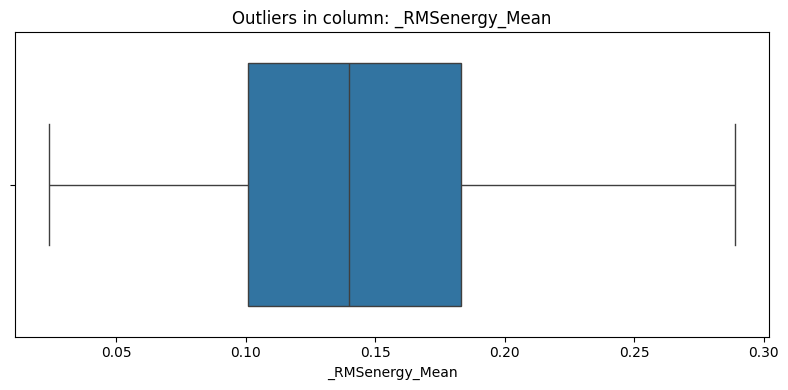

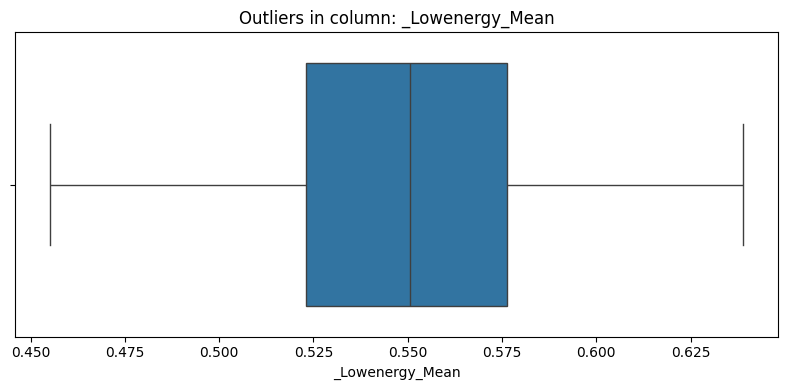

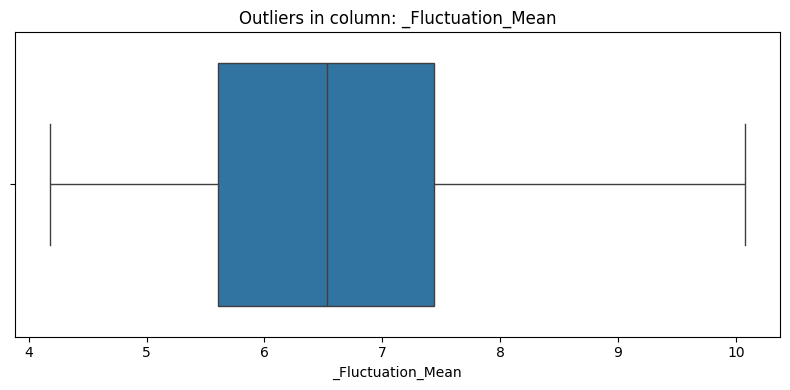

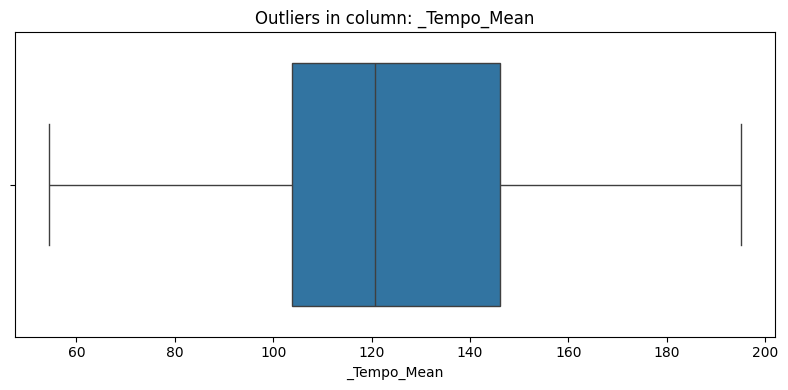

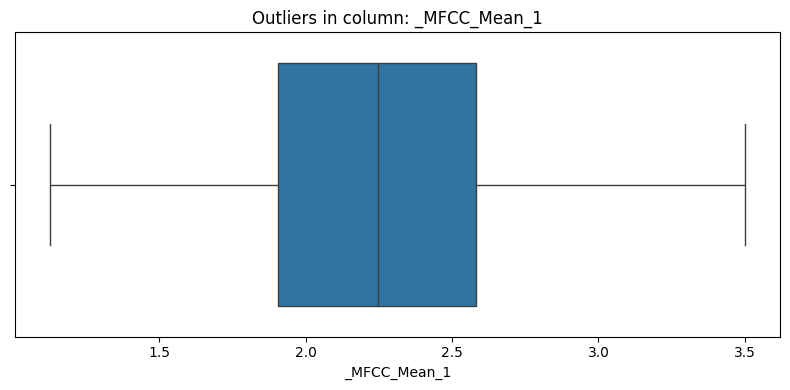

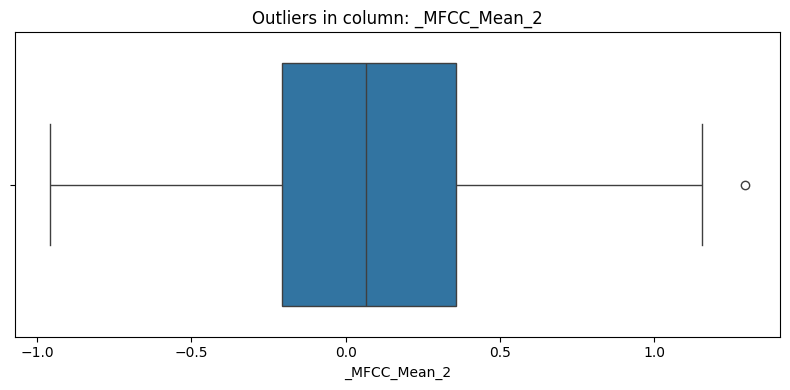

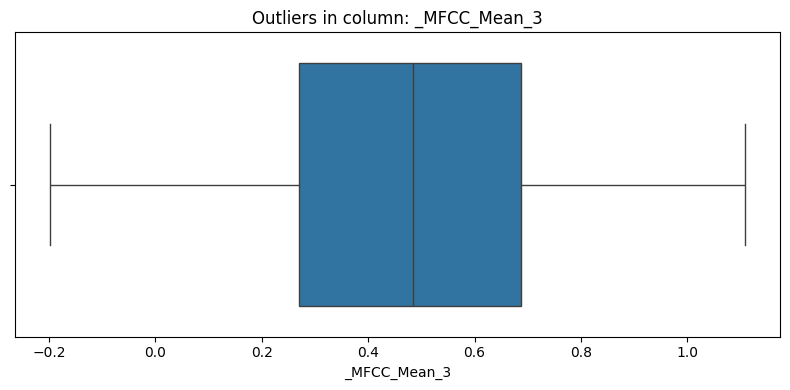

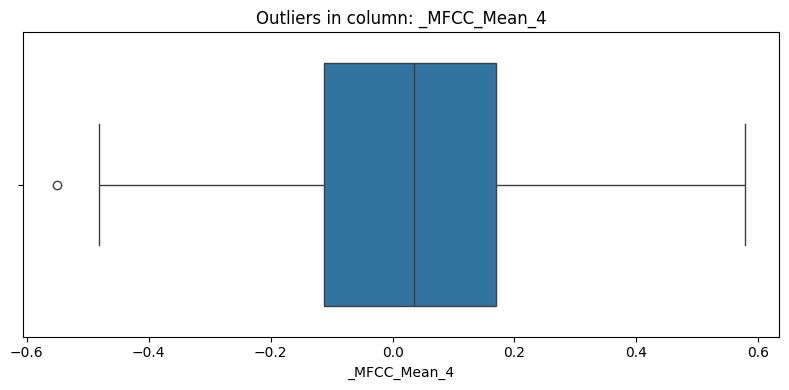

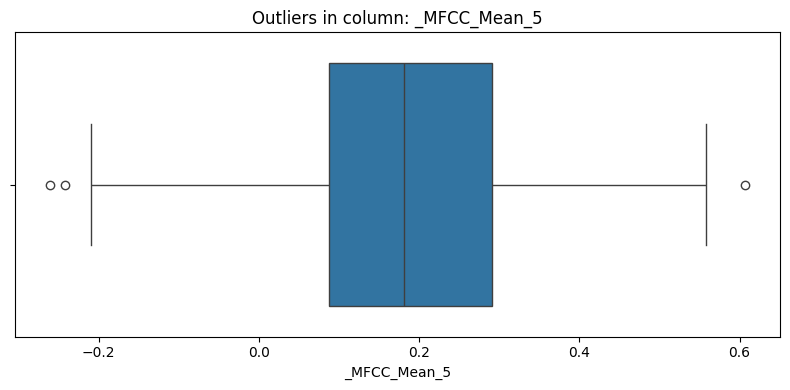

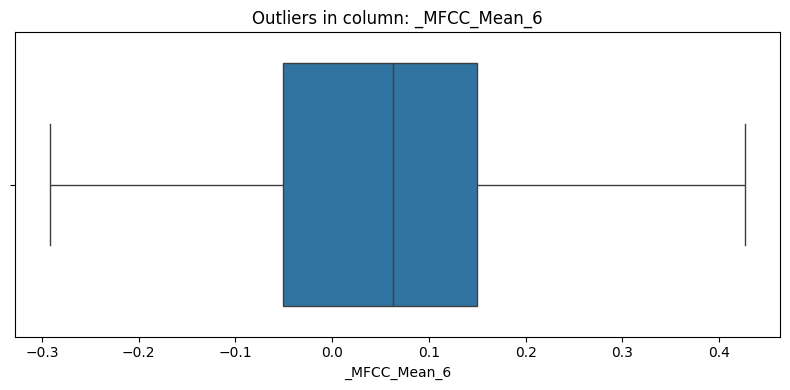

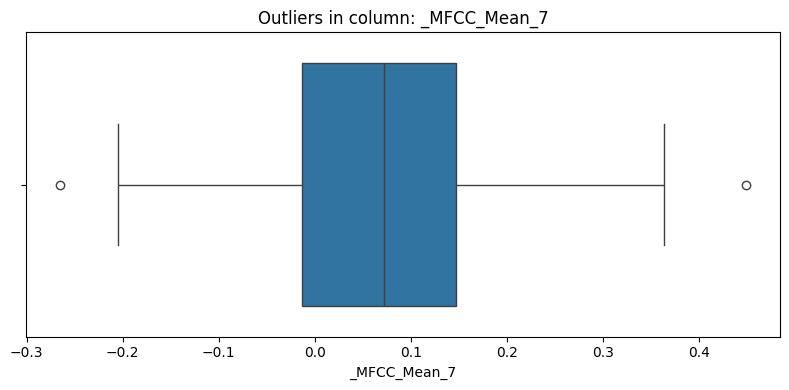

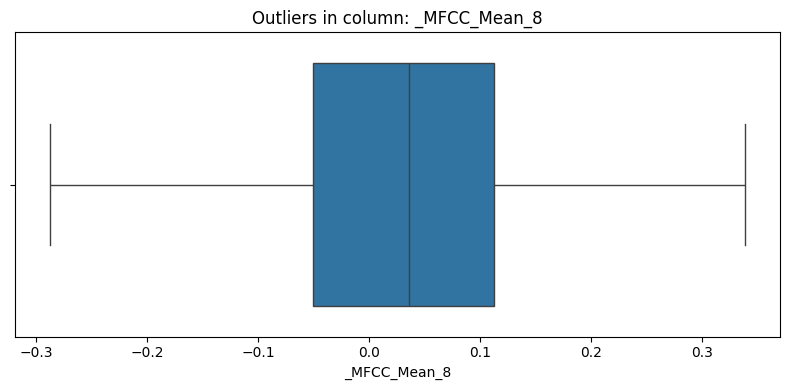

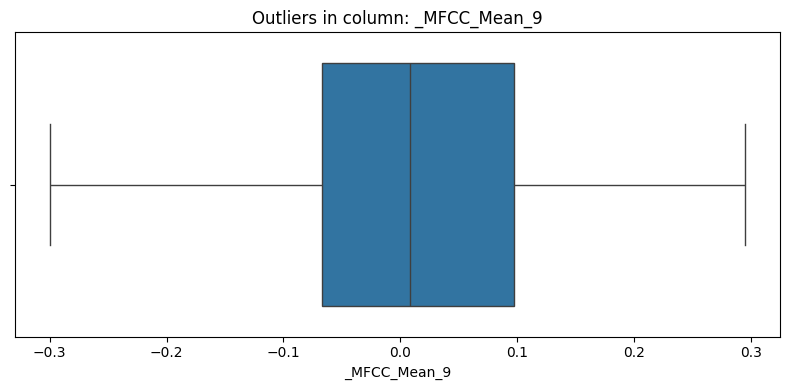

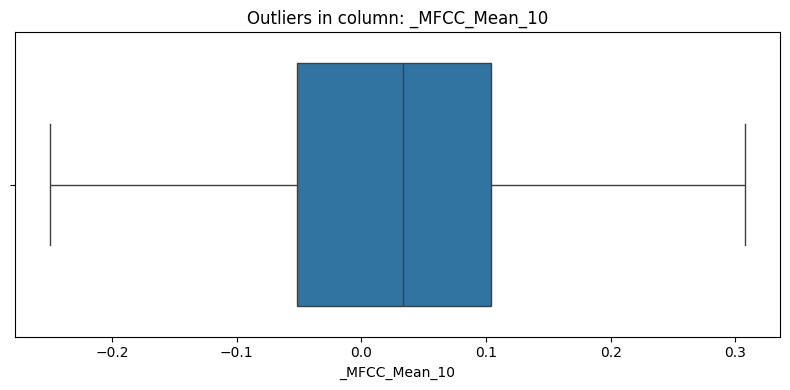

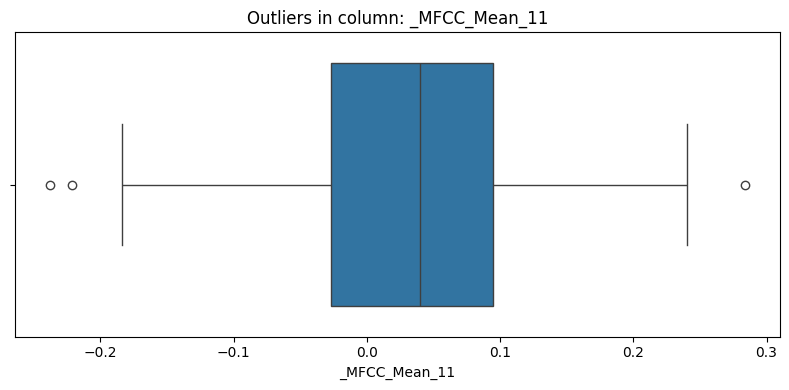

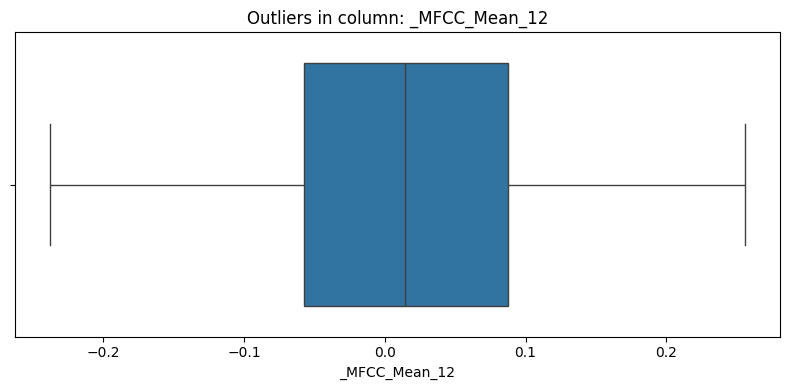

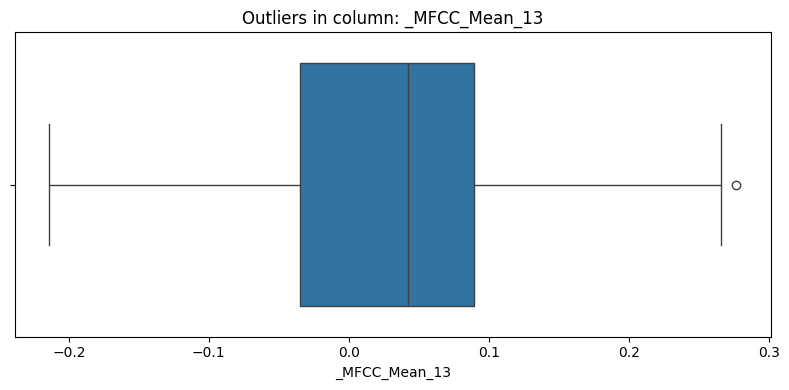

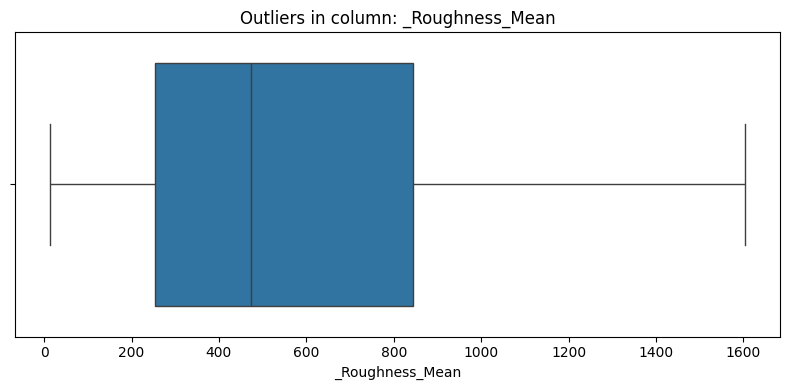

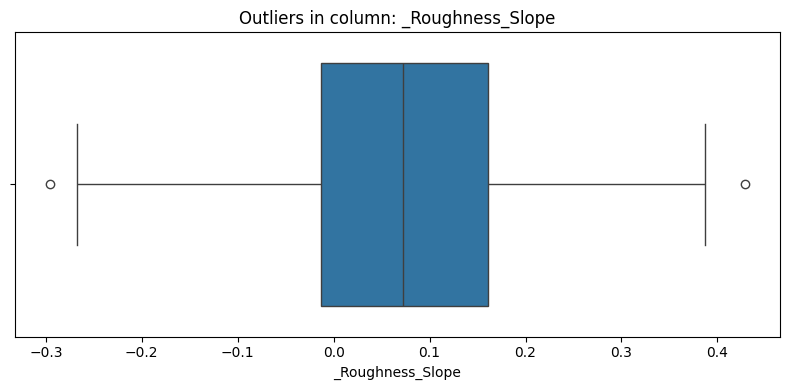

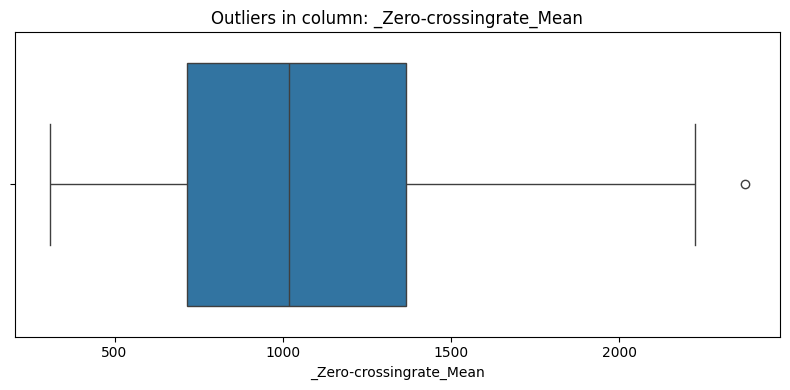

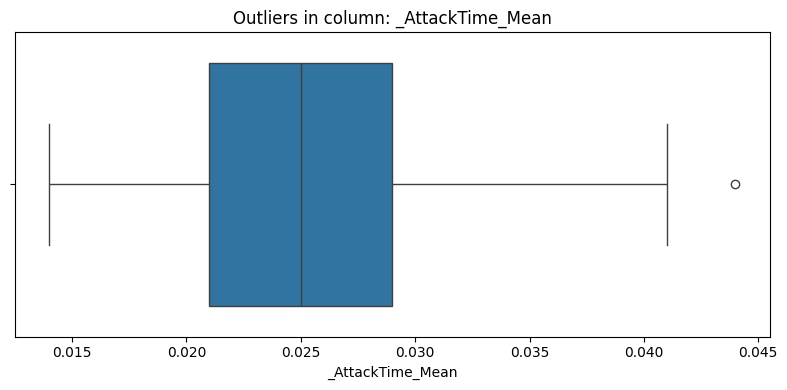

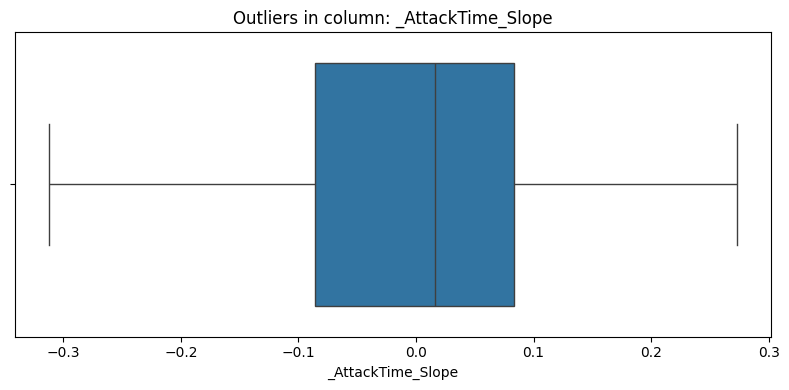

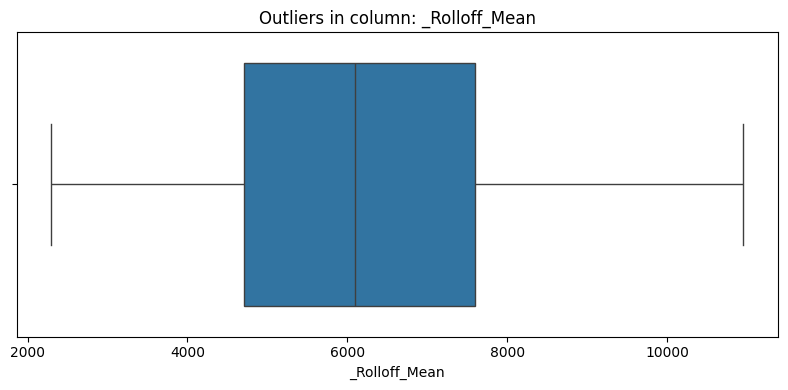

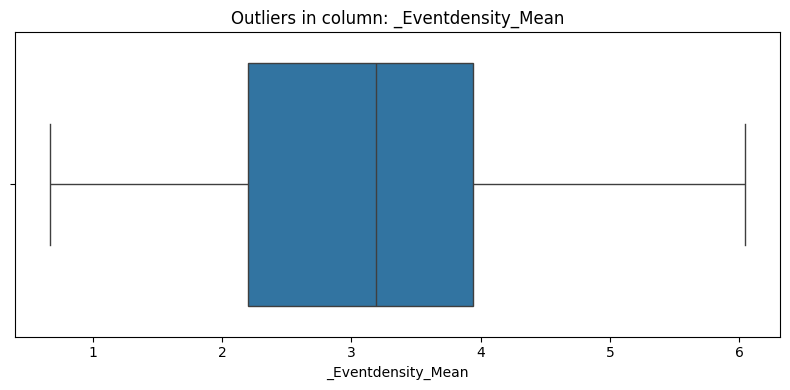

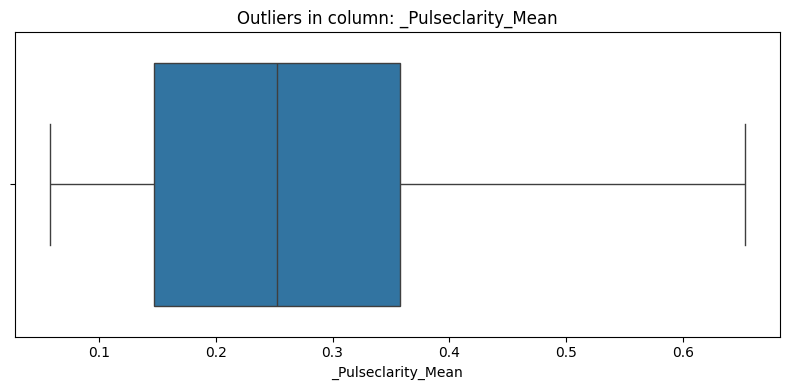

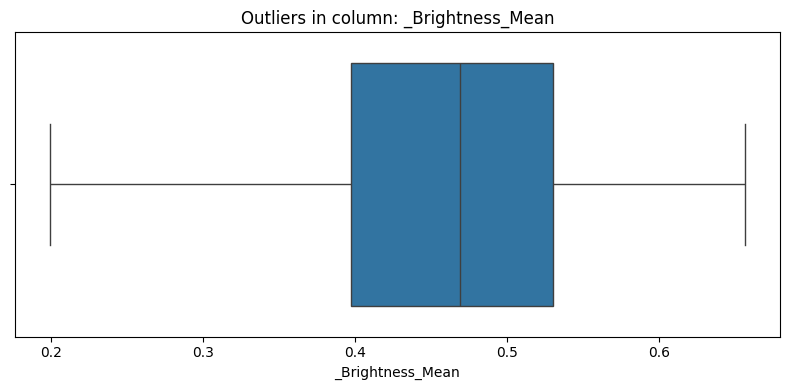

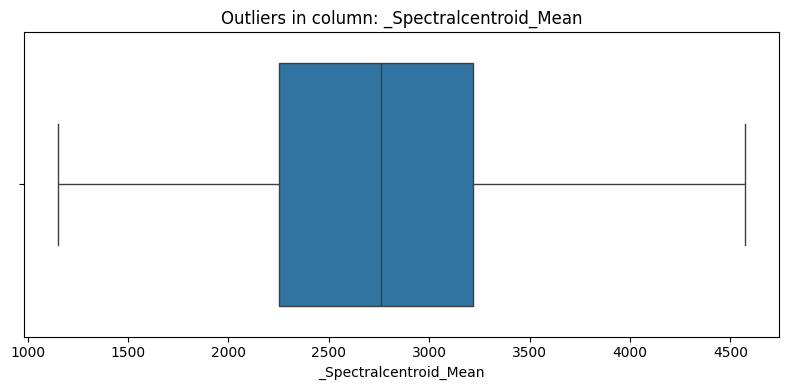

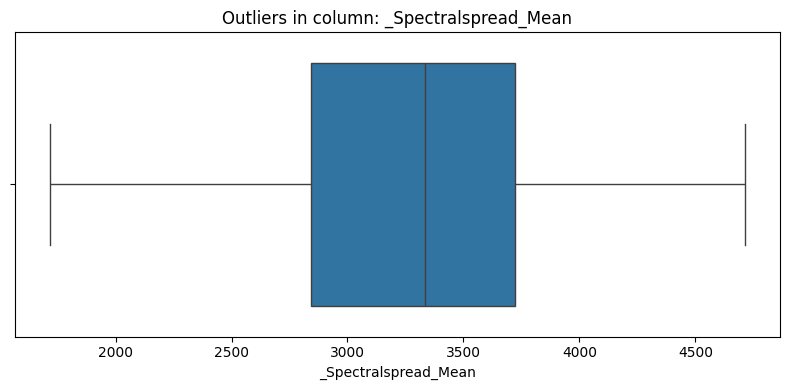

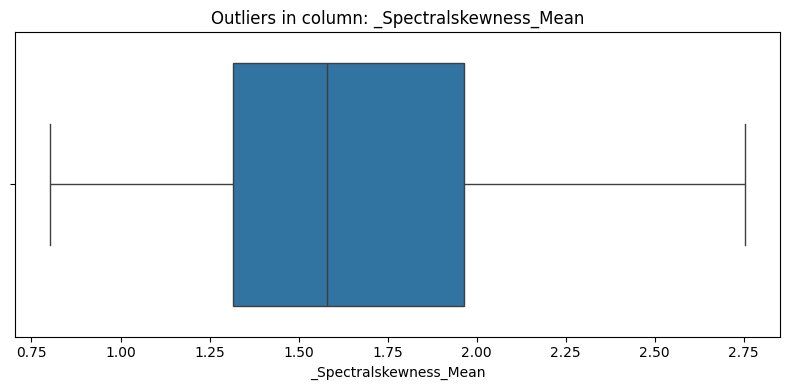

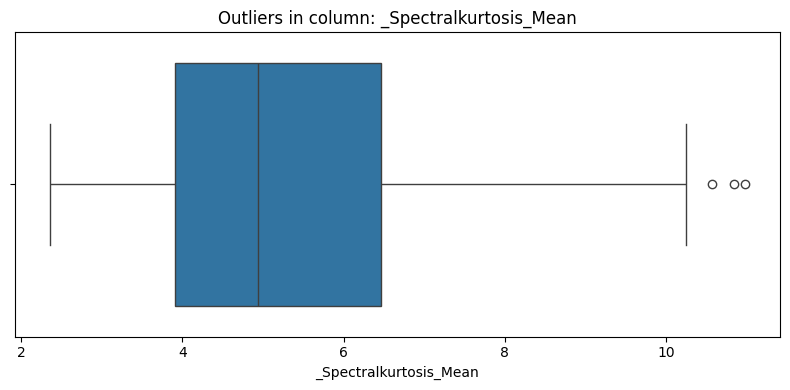

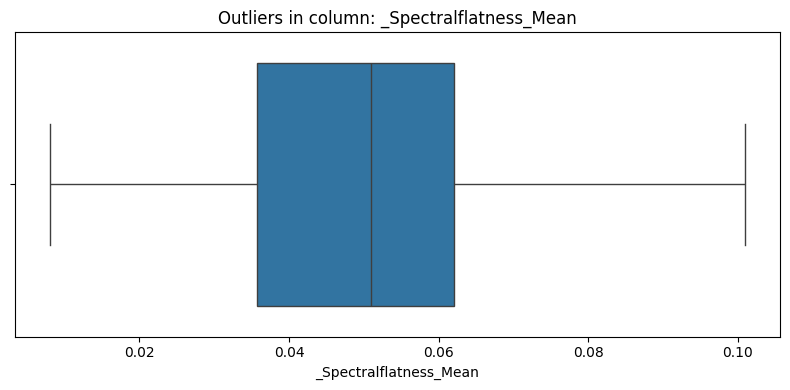

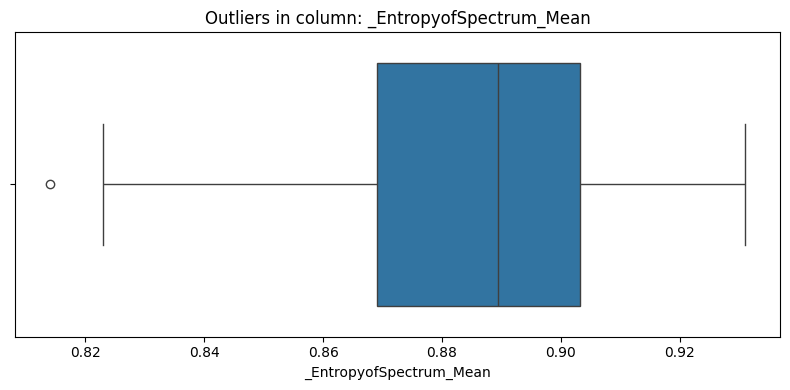

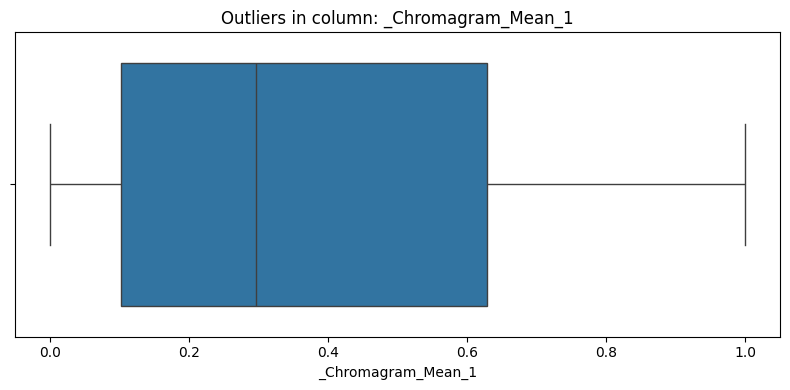

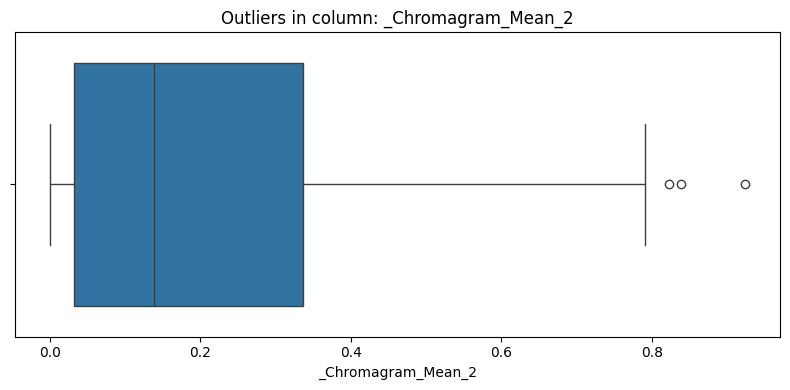

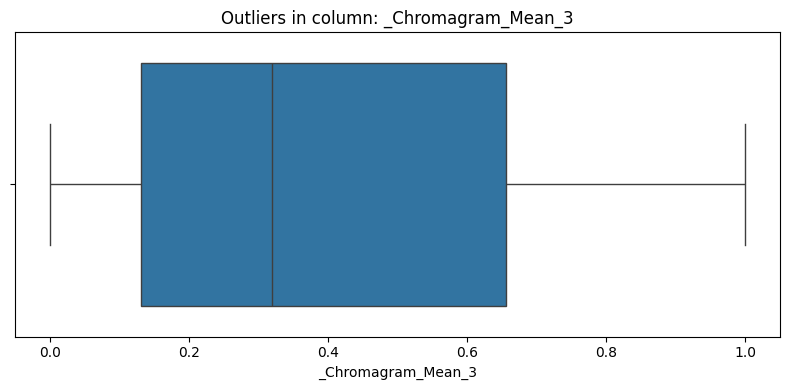

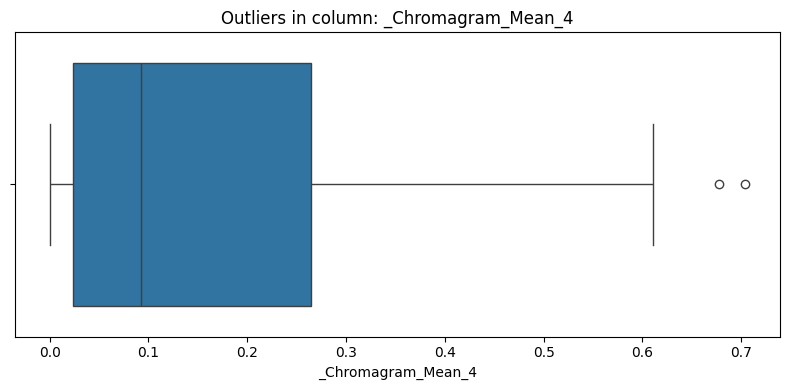

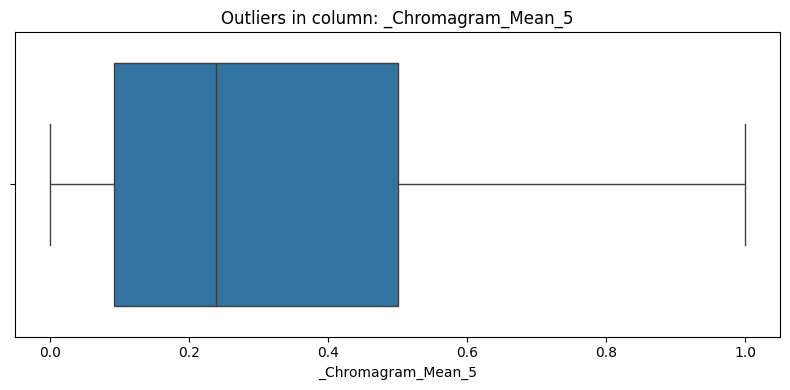

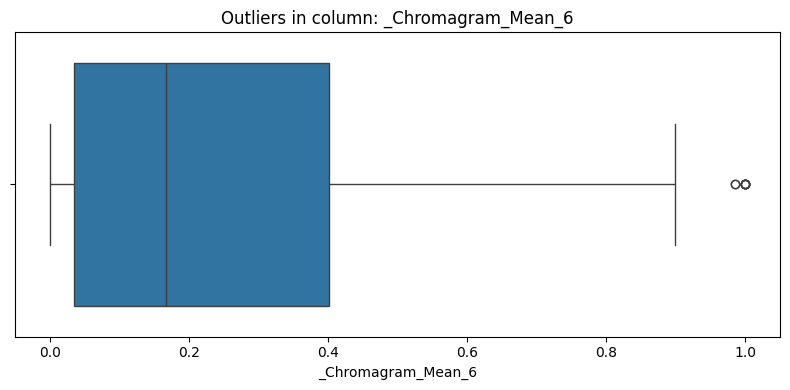

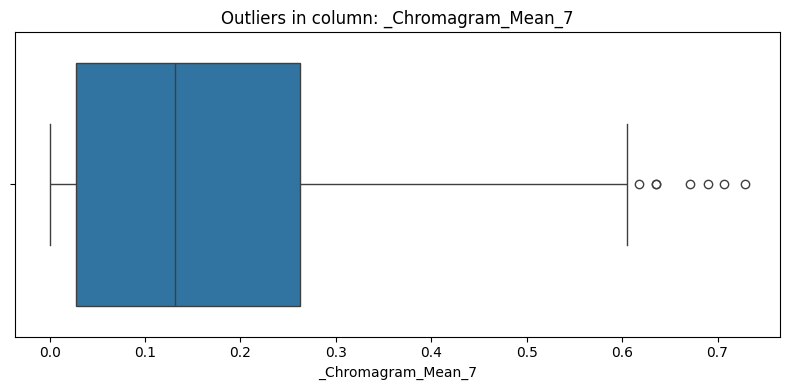

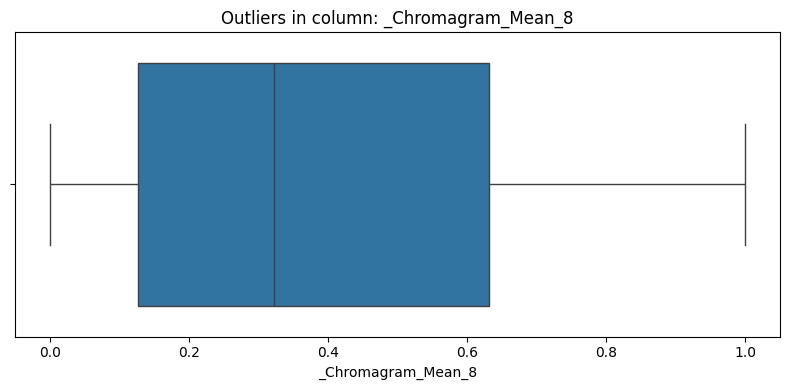

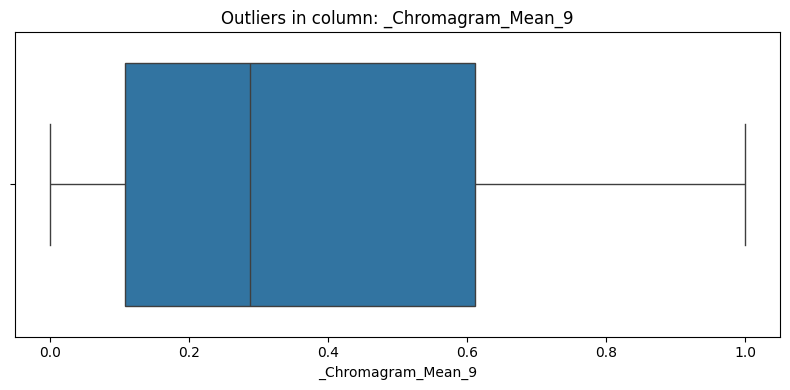

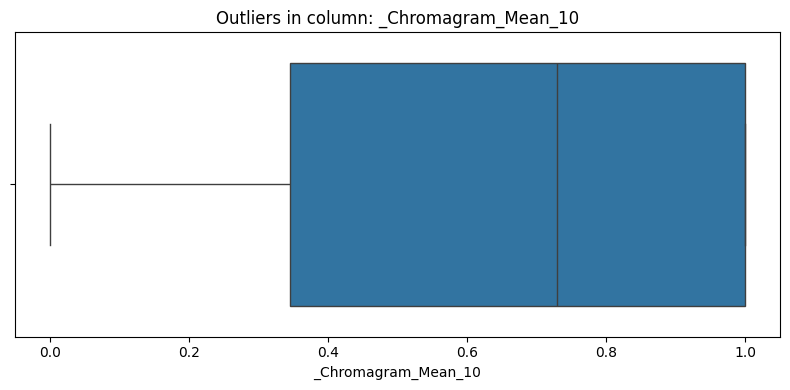

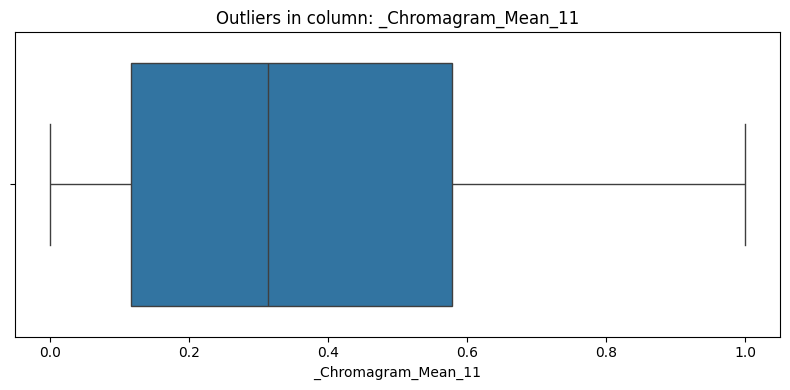

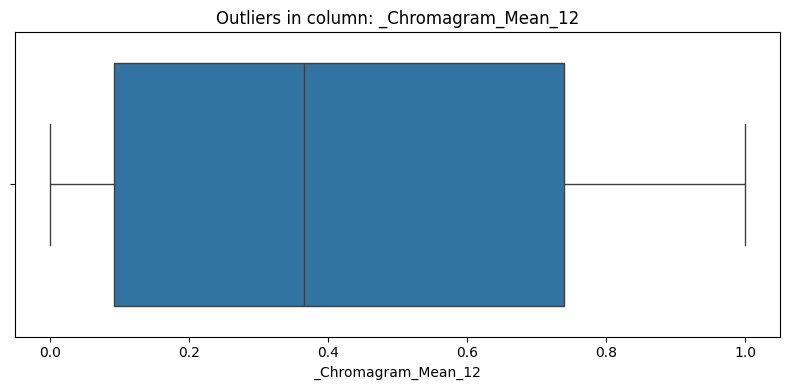

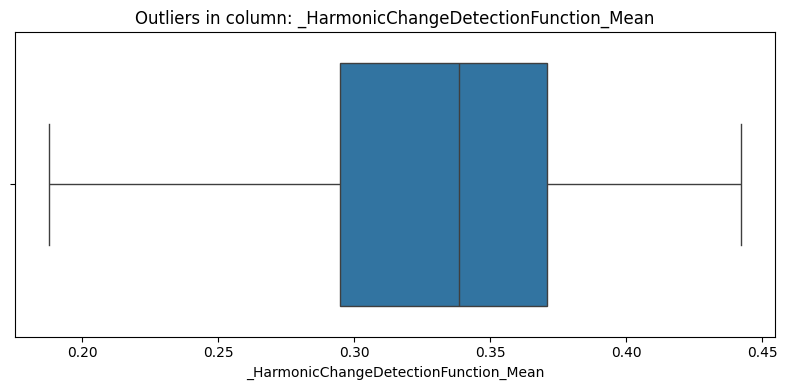

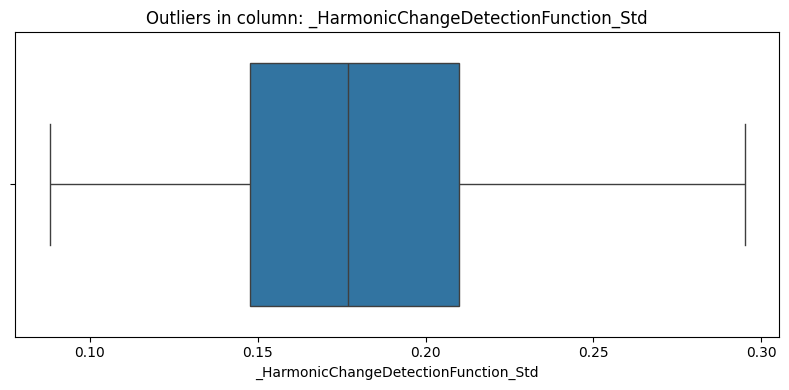

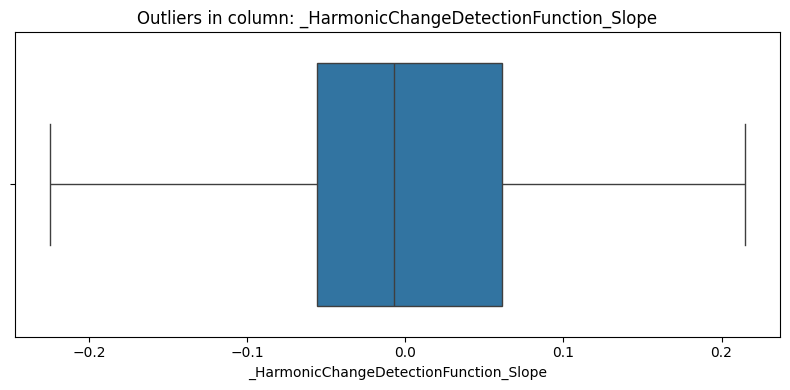

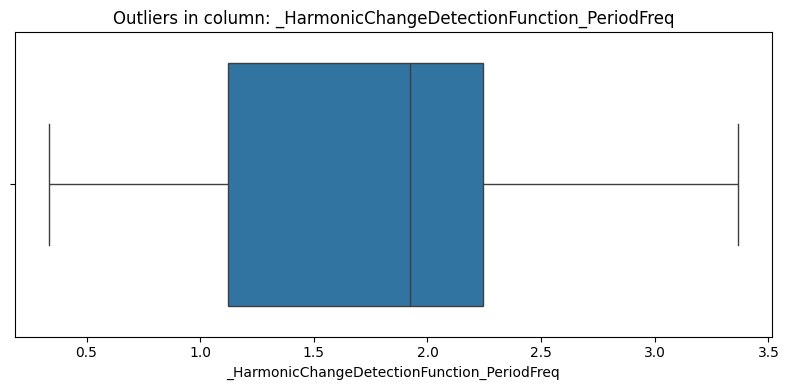

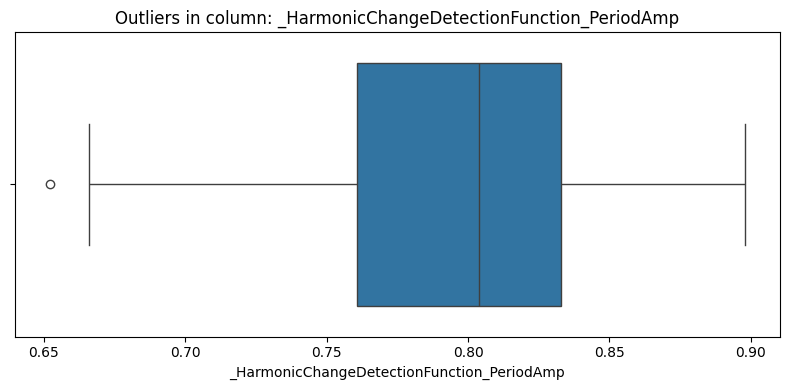

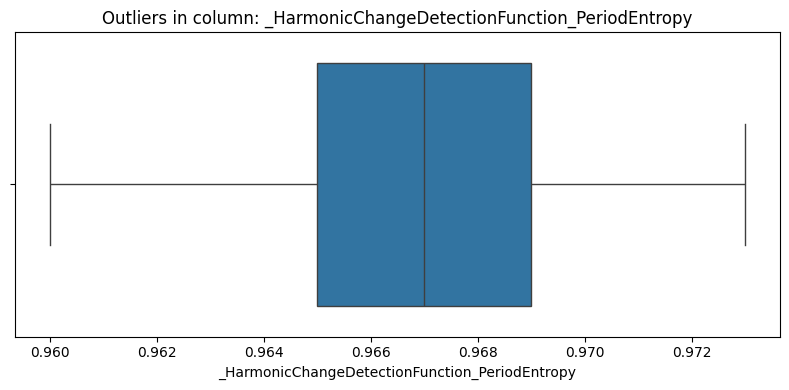

In [117]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f'Outliers in column: {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

## **EDA**

In [118]:
df.describe()

,_RMSenergy_Mean,_Lowenergy_Mean,_Fluctuation_Mean,_Tempo_Mean,_MFCC_Mean_1,_MFCC_Mean_2,_MFCC_Mean_3,_MFCC_Mean_4,_MFCC_Mean_5,_MFCC_Mean_6,...,_Chromagram_Mean_9,_Chromagram_Mean_10,_Chromagram_Mean_11,_Chromagram_Mean_12,_HarmonicChangeDetectionFunction_Mean,_HarmonicChangeDetectionFunction_Std,_HarmonicChangeDetectionFunction_Slope,_HarmonicChangeDetectionFunction_PeriodFreq,_HarmonicChangeDetectionFunction_PeriodAmp,_HarmonicChangeDetectionFunction_PeriodEntropy
count,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,...,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000,152.000000
mean,0.140914,0.549513,6.591776,124.542322,2.247783,0.074533,0.490309,0.029803,0.186638,0.049243,...,0.373059,0.644664,0.373697,0.423336,0.329763,0.178421,-0.002184,1.808500,0.795763,0.966967
std,0.055176,0.037433,1.338333,32.777001,0.489211,0.432812,0.263231,0.211857,0.166896,0.151657,...,0.315190,0.337528,0.297236,0.354047,0.051337,0.038837,0.097716,0.837001,0.050934,0.002695
min,0.024000,0.455000,4.178000,54.514000,1.126000,-0.959000,-0.199000,-0.550000,-0.261000,-0.292000,...,0.000000,0.000000,0.000000,0.000000,0.188000,0.088000,-0.225000,0.336000,0.652000,0.960000
25%,0.101000,0.523000,5.604250,103.784250,1.906500,-0.207500,0.270500,-0.113250,0.087000,-0.050750,...,0.107750,0.345250,0.116500,0.092500,0.294750,0.147750,-0.055750,1.121000,0.760750,0.965000
50%,0.140000,0.550500,6.535000,120.752000,2.247500,0.067000,0.485000,0.035500,0.181000,0.062500,...,0.287500,0.729500,0.313500,0.365500,0.338500,0.177000,-0.007000,1.922000,0.804000,0.967000
75%,0.183250,0.576250,7.436750,146.179500,2.580250,0.357250,0.688000,0.169250,0.291500,0.150250,...,0.611500,1.000000,0.578000,0.739750,0.371000,0.210000,0.061000,2.243000,0.833000,0.969000
max,0.289000,0.639000,10.080000,195.026000,3.501000,1.294000,1.109000,0.578000,0.607000,0.427000,...,1.000000,1.000000,1.000000,1.000000,0.442000,0.295000,0.215000,3.364000,0.898000,0.973000


## Variable distributions

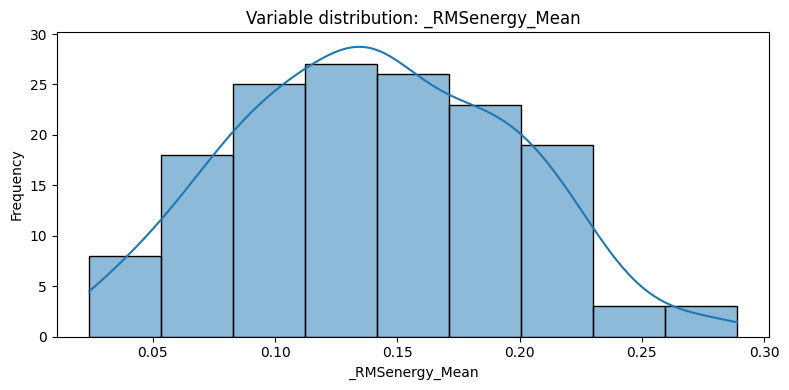

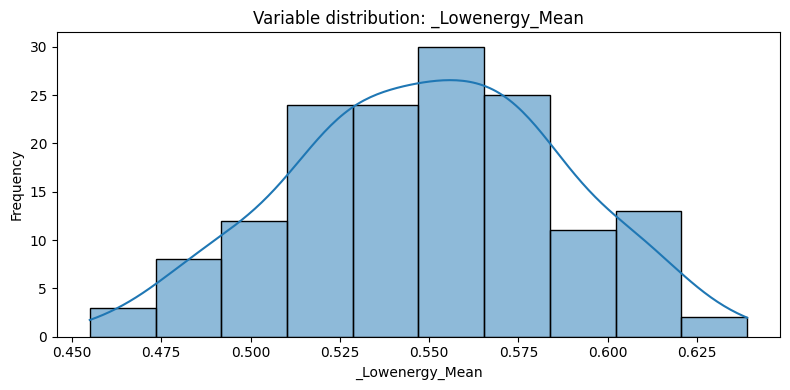

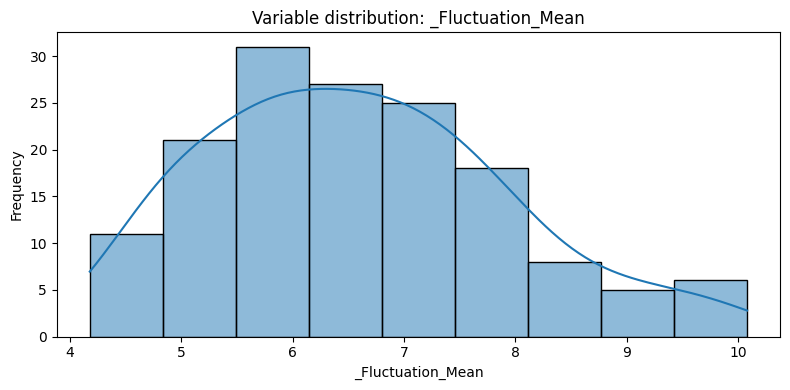

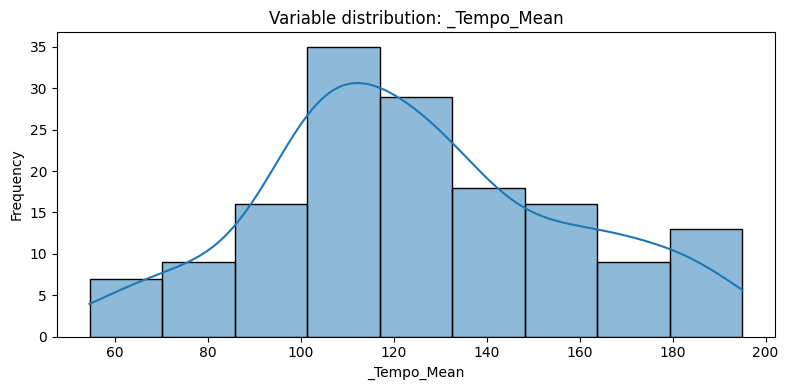

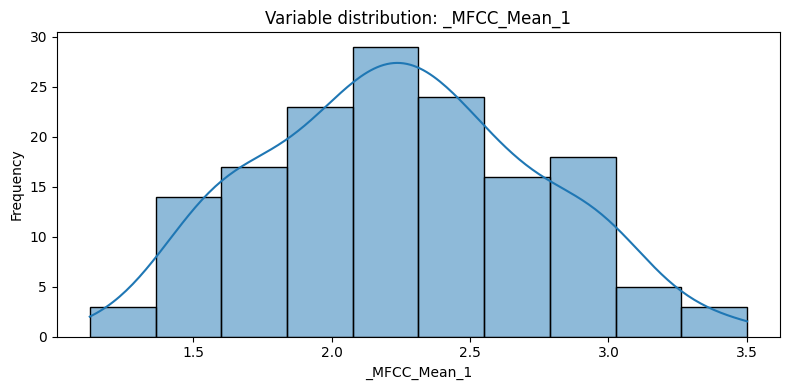

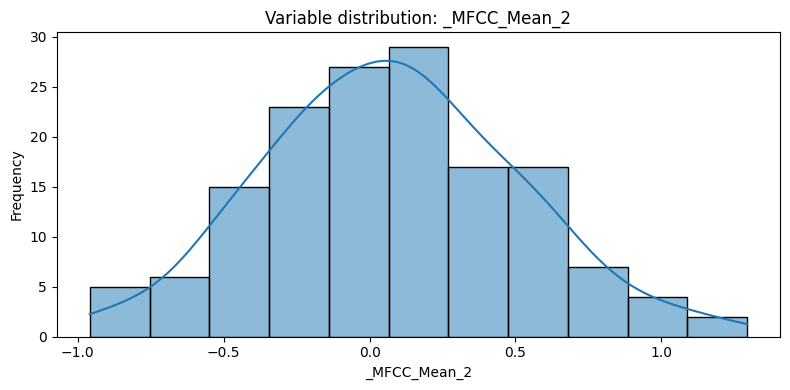

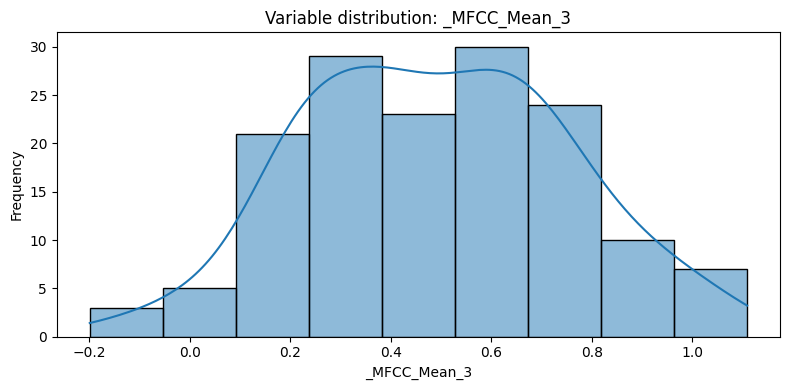

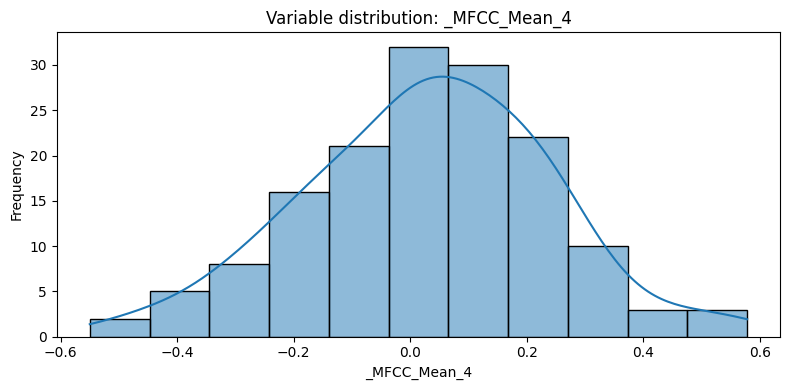

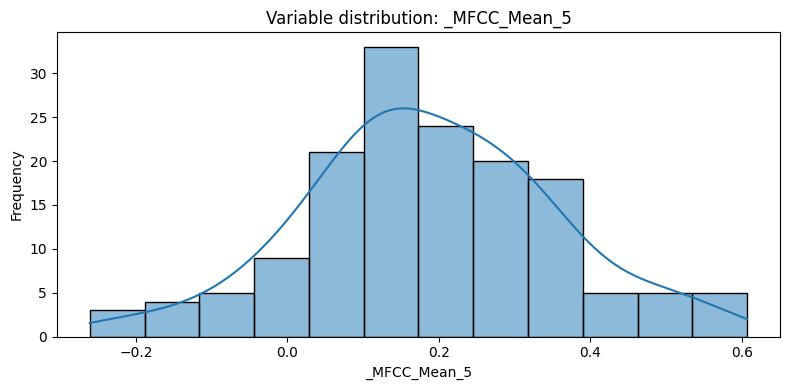

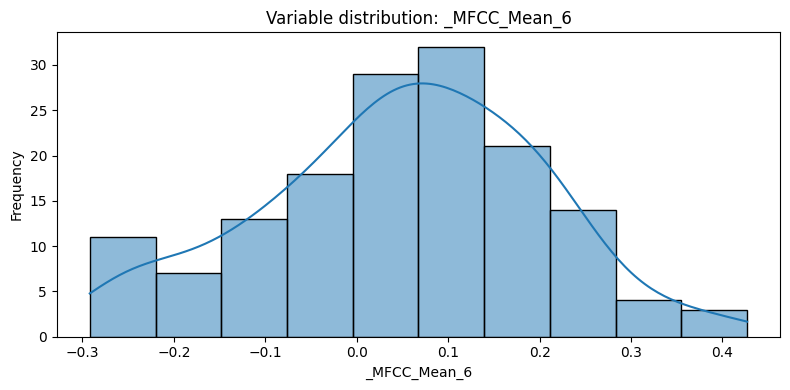

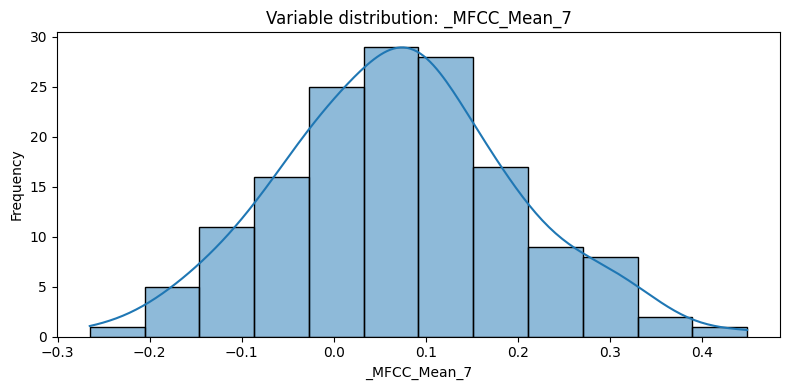

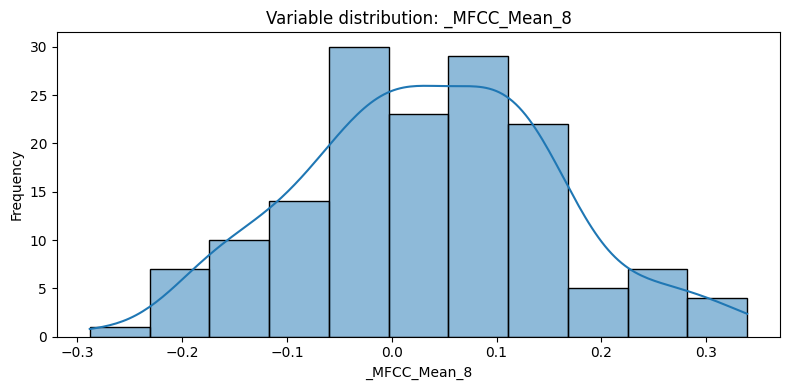

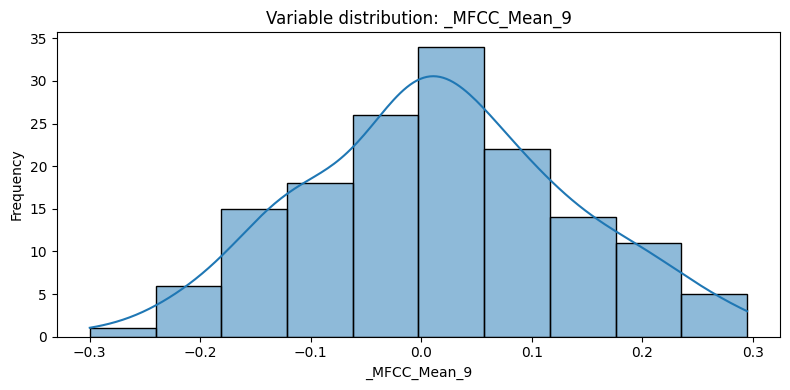

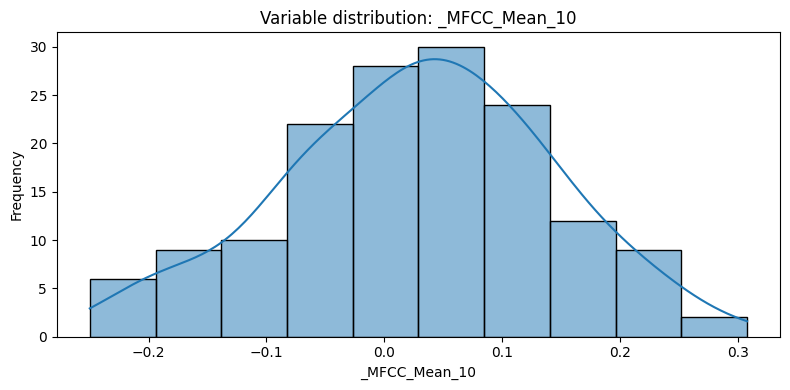

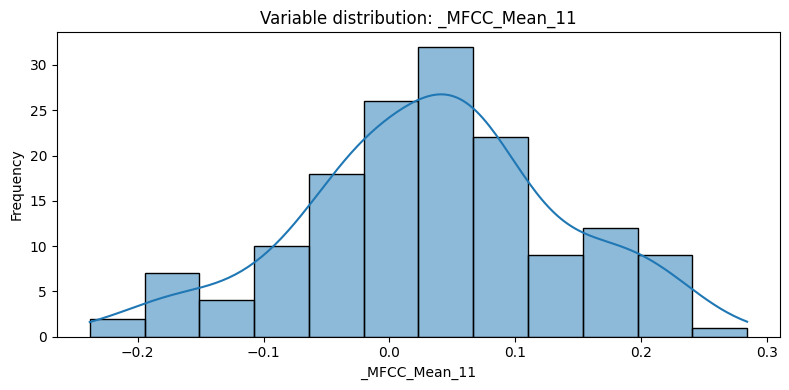

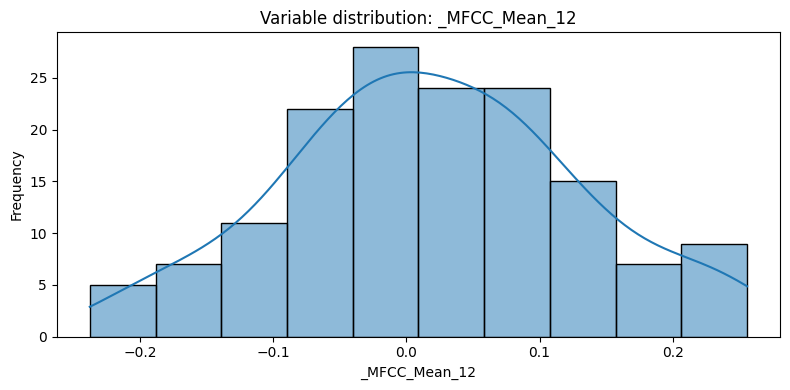

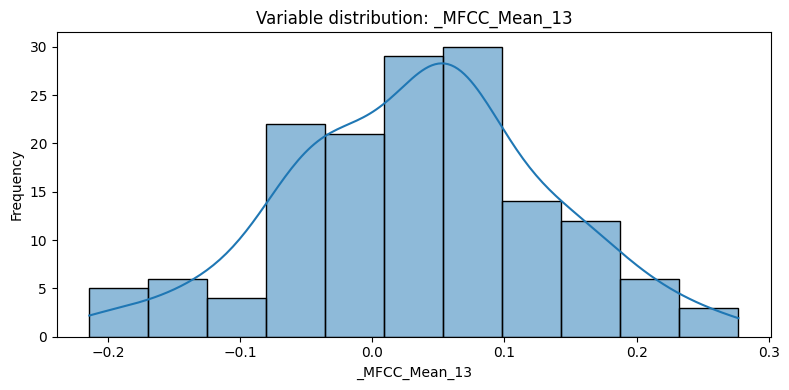

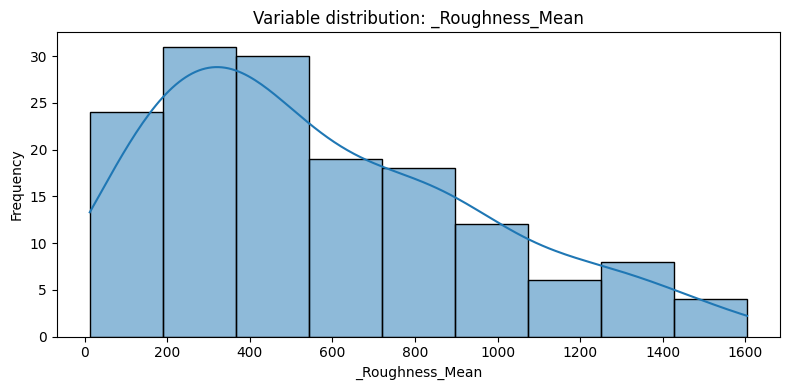

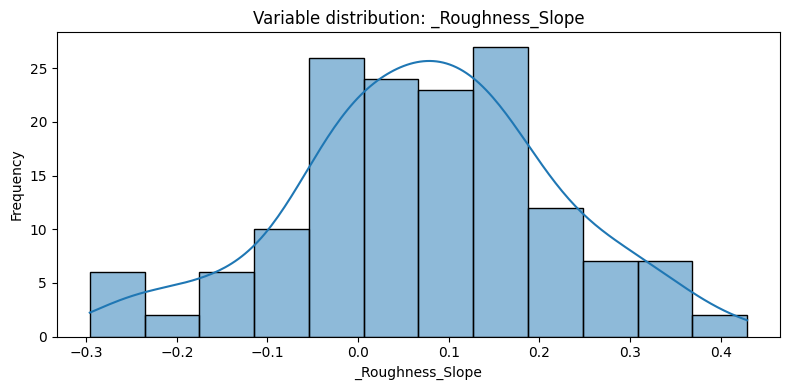

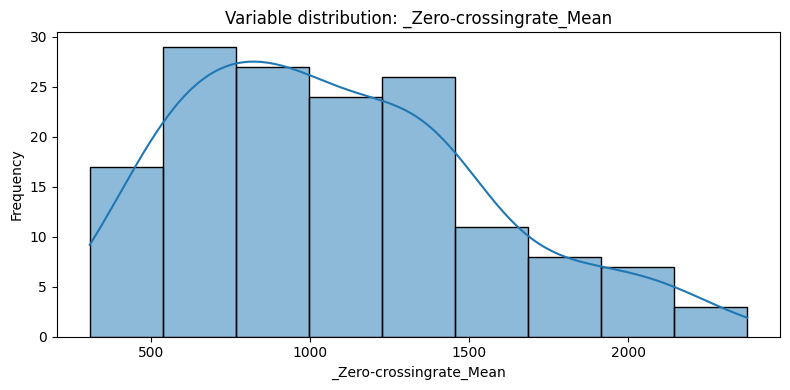

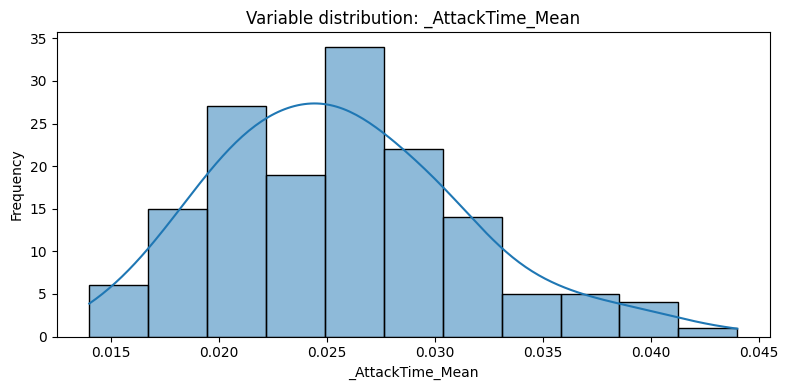

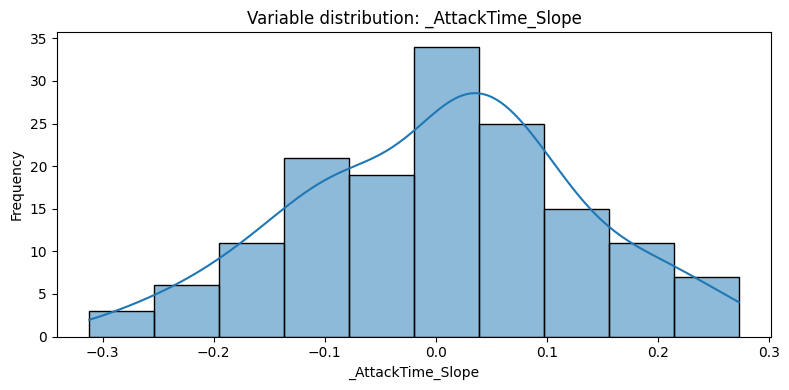

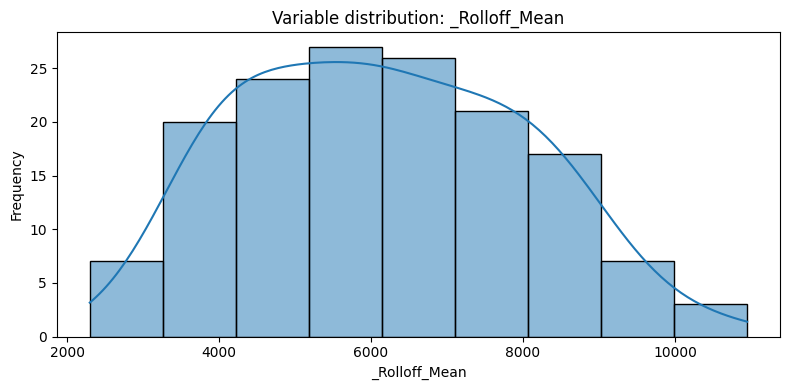

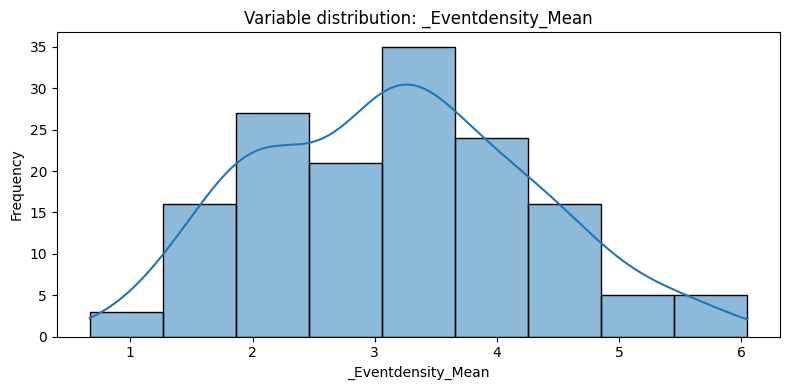

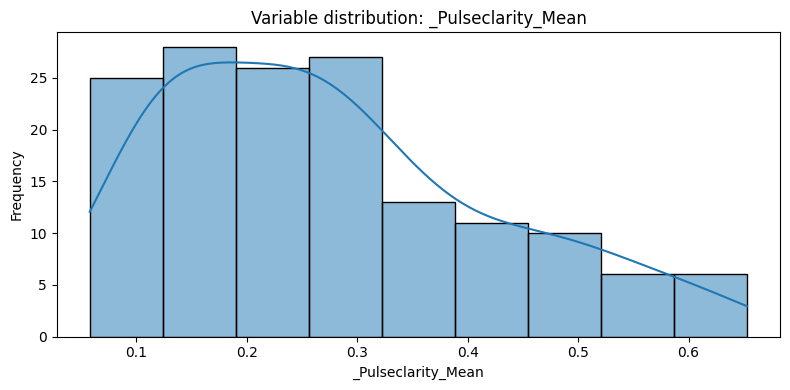

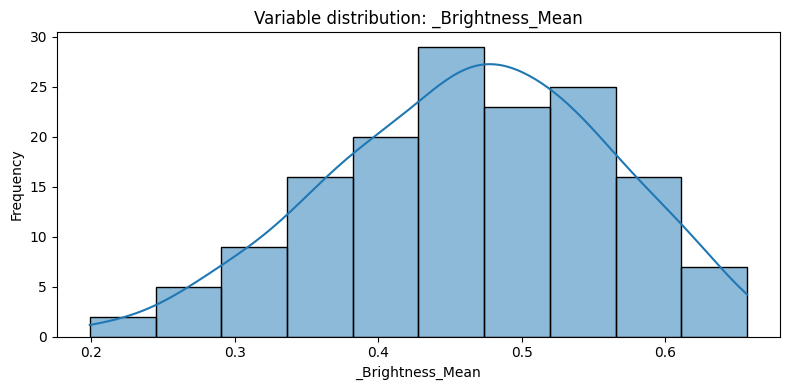

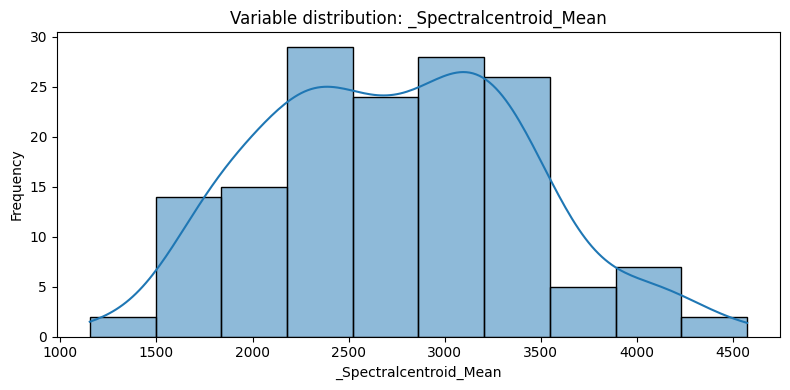

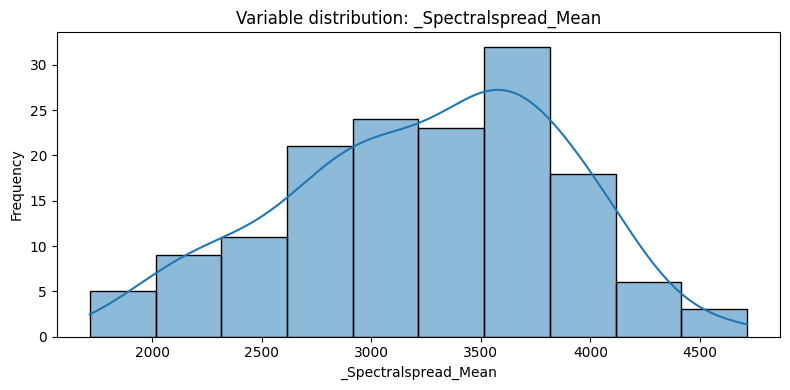

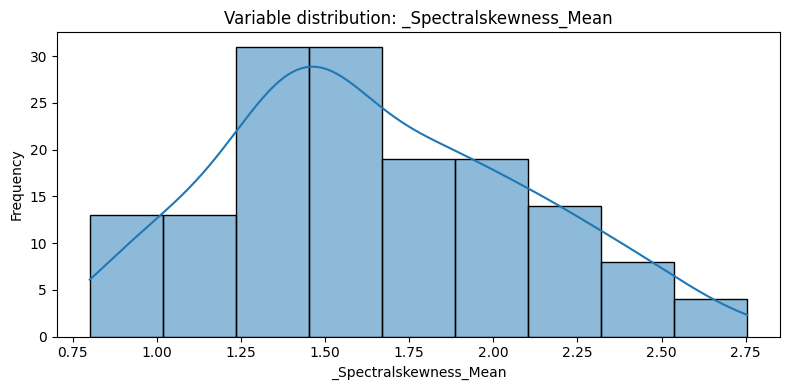

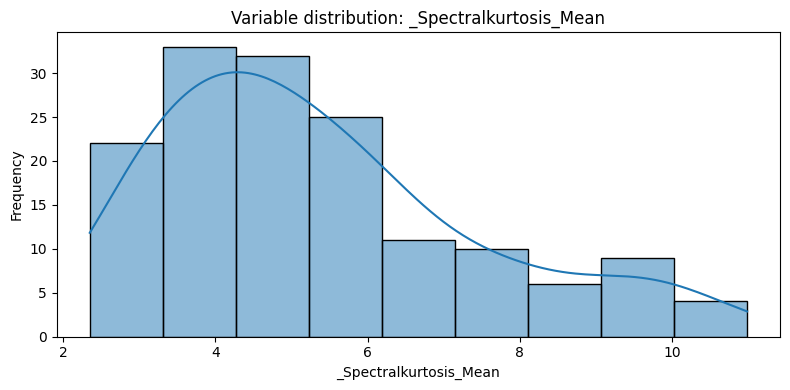

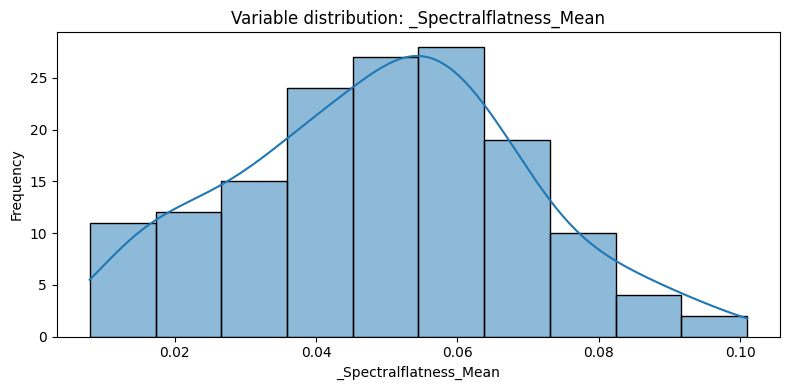

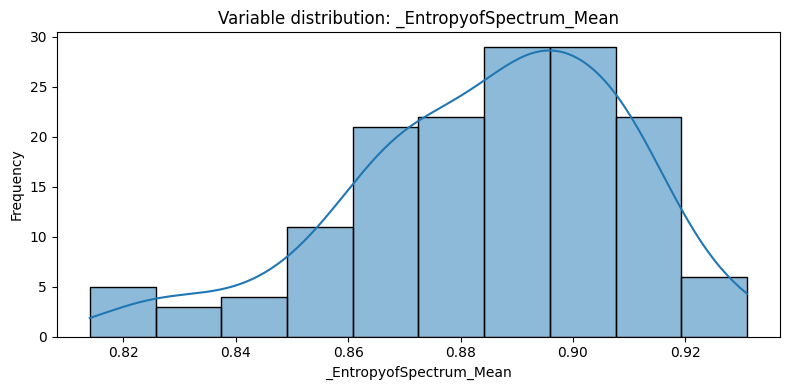

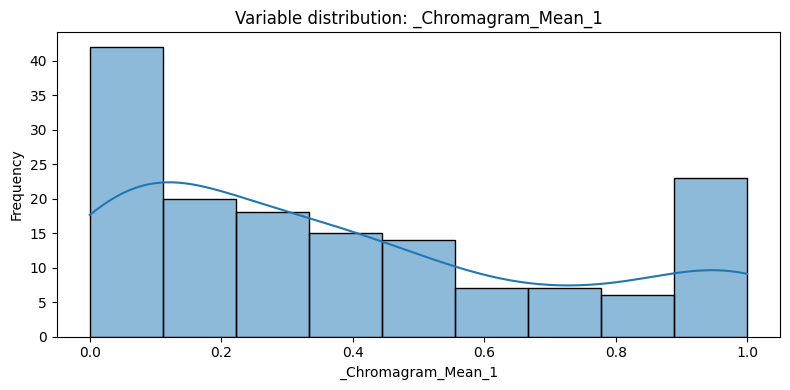

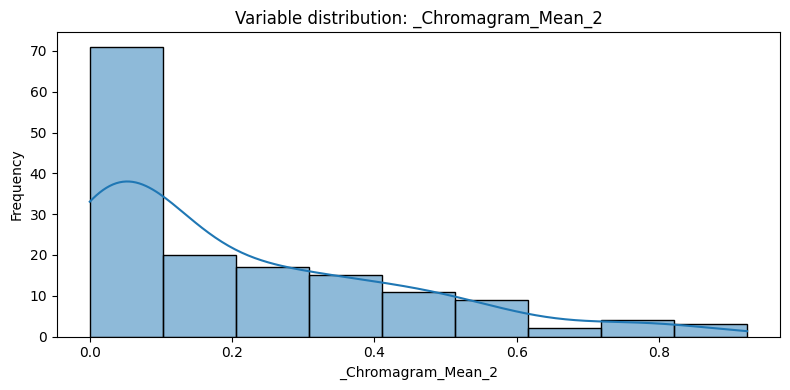

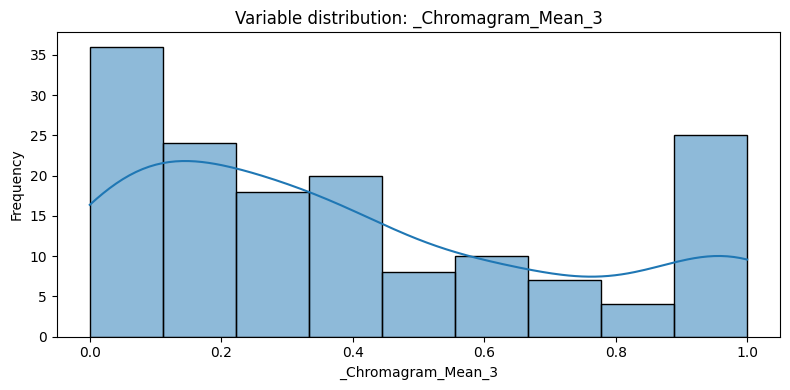

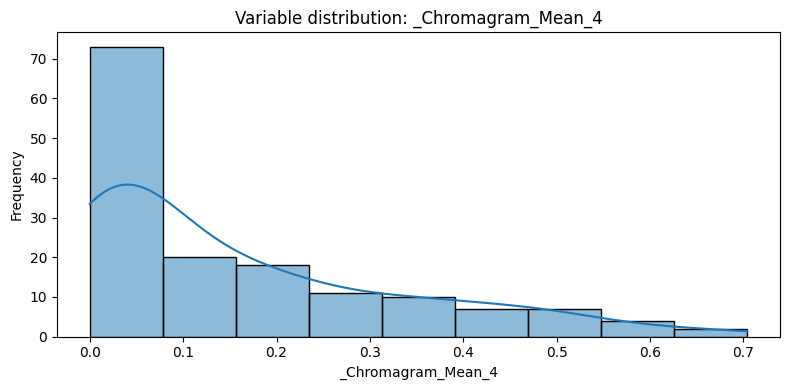

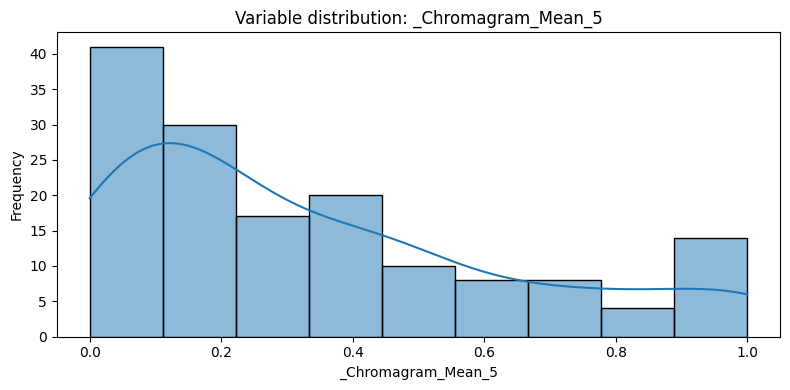

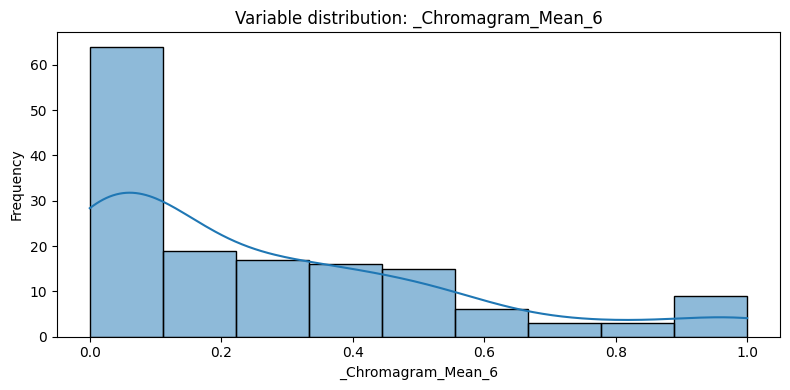

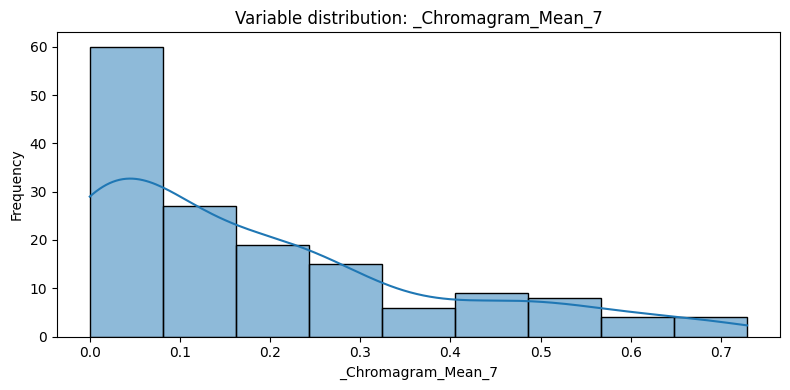

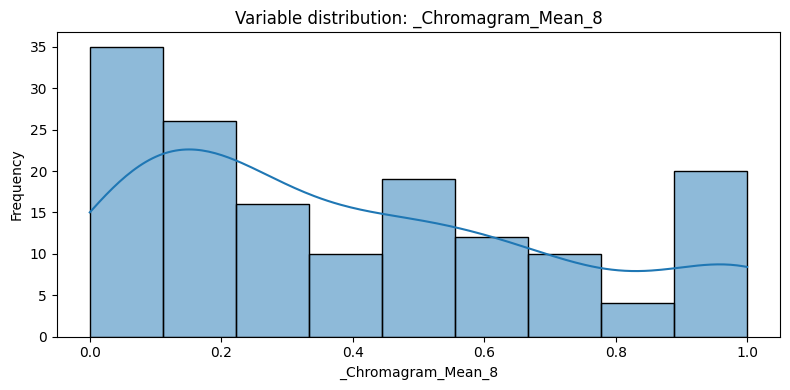

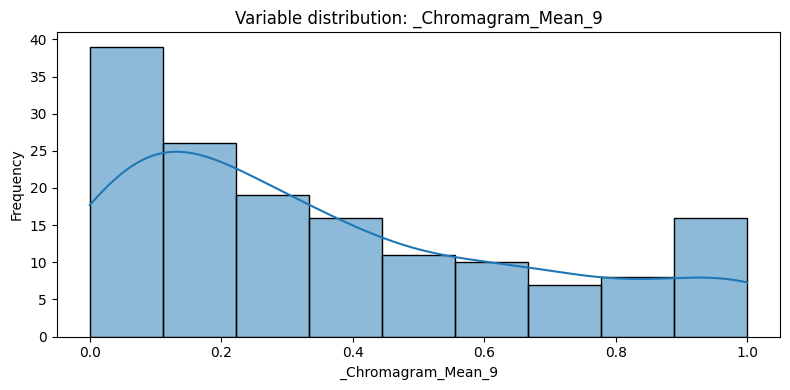

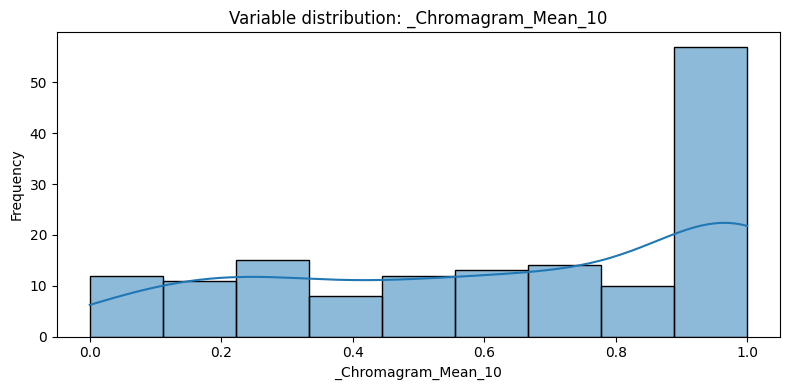

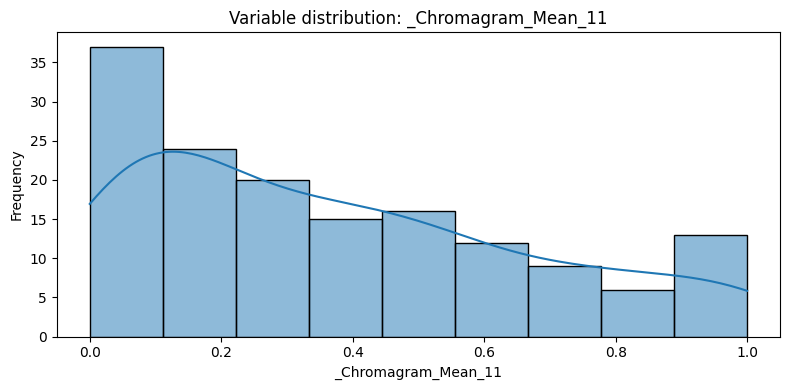

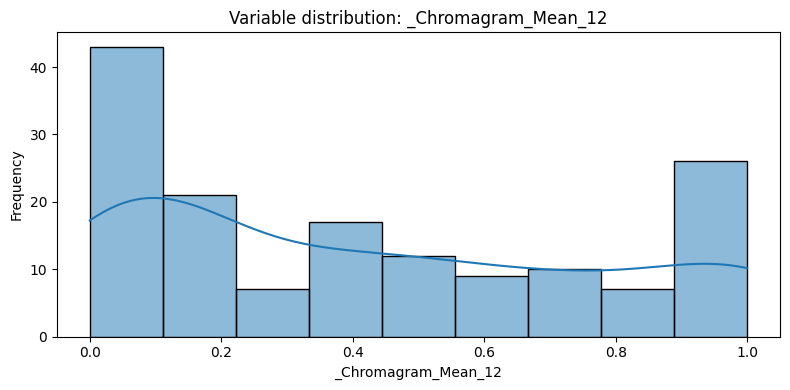

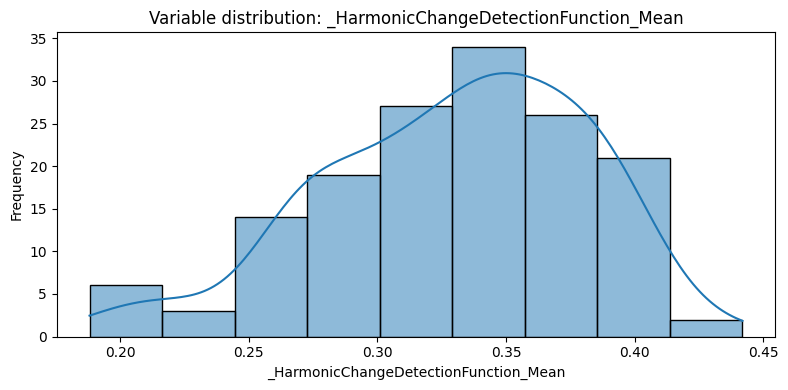

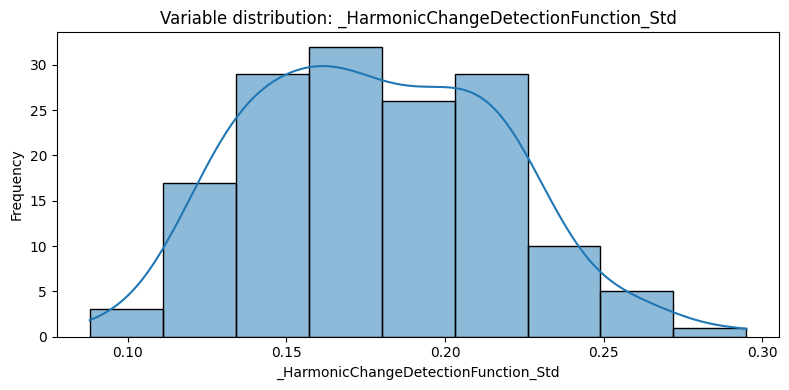

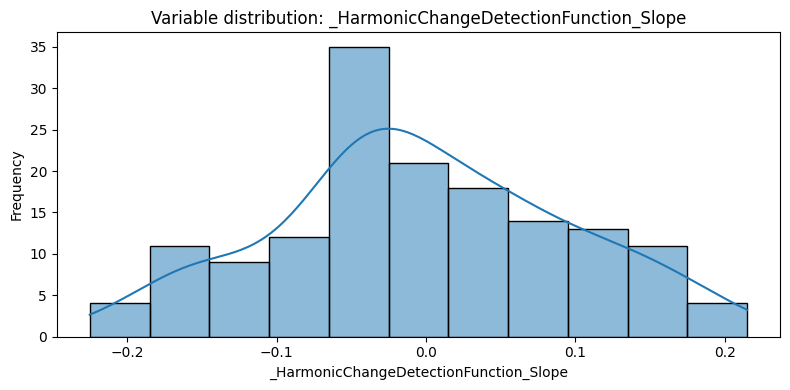

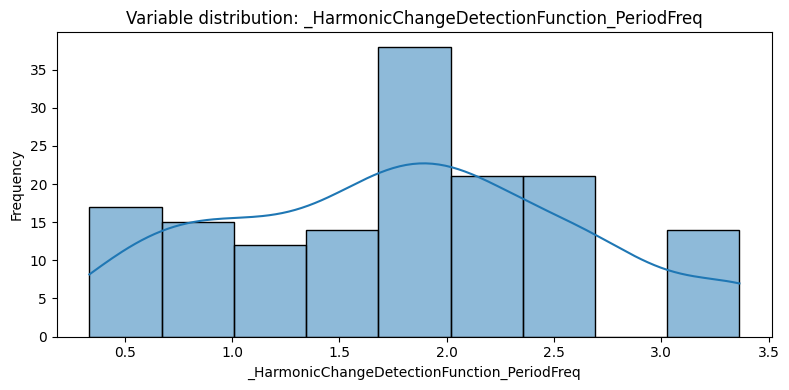

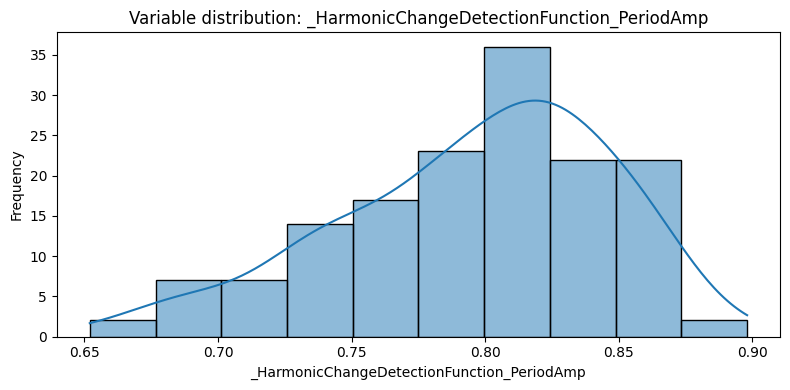

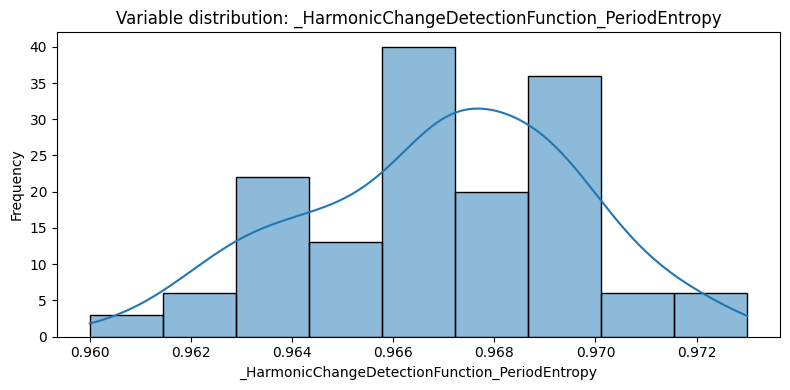

In [119]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Variable distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


## Correlations

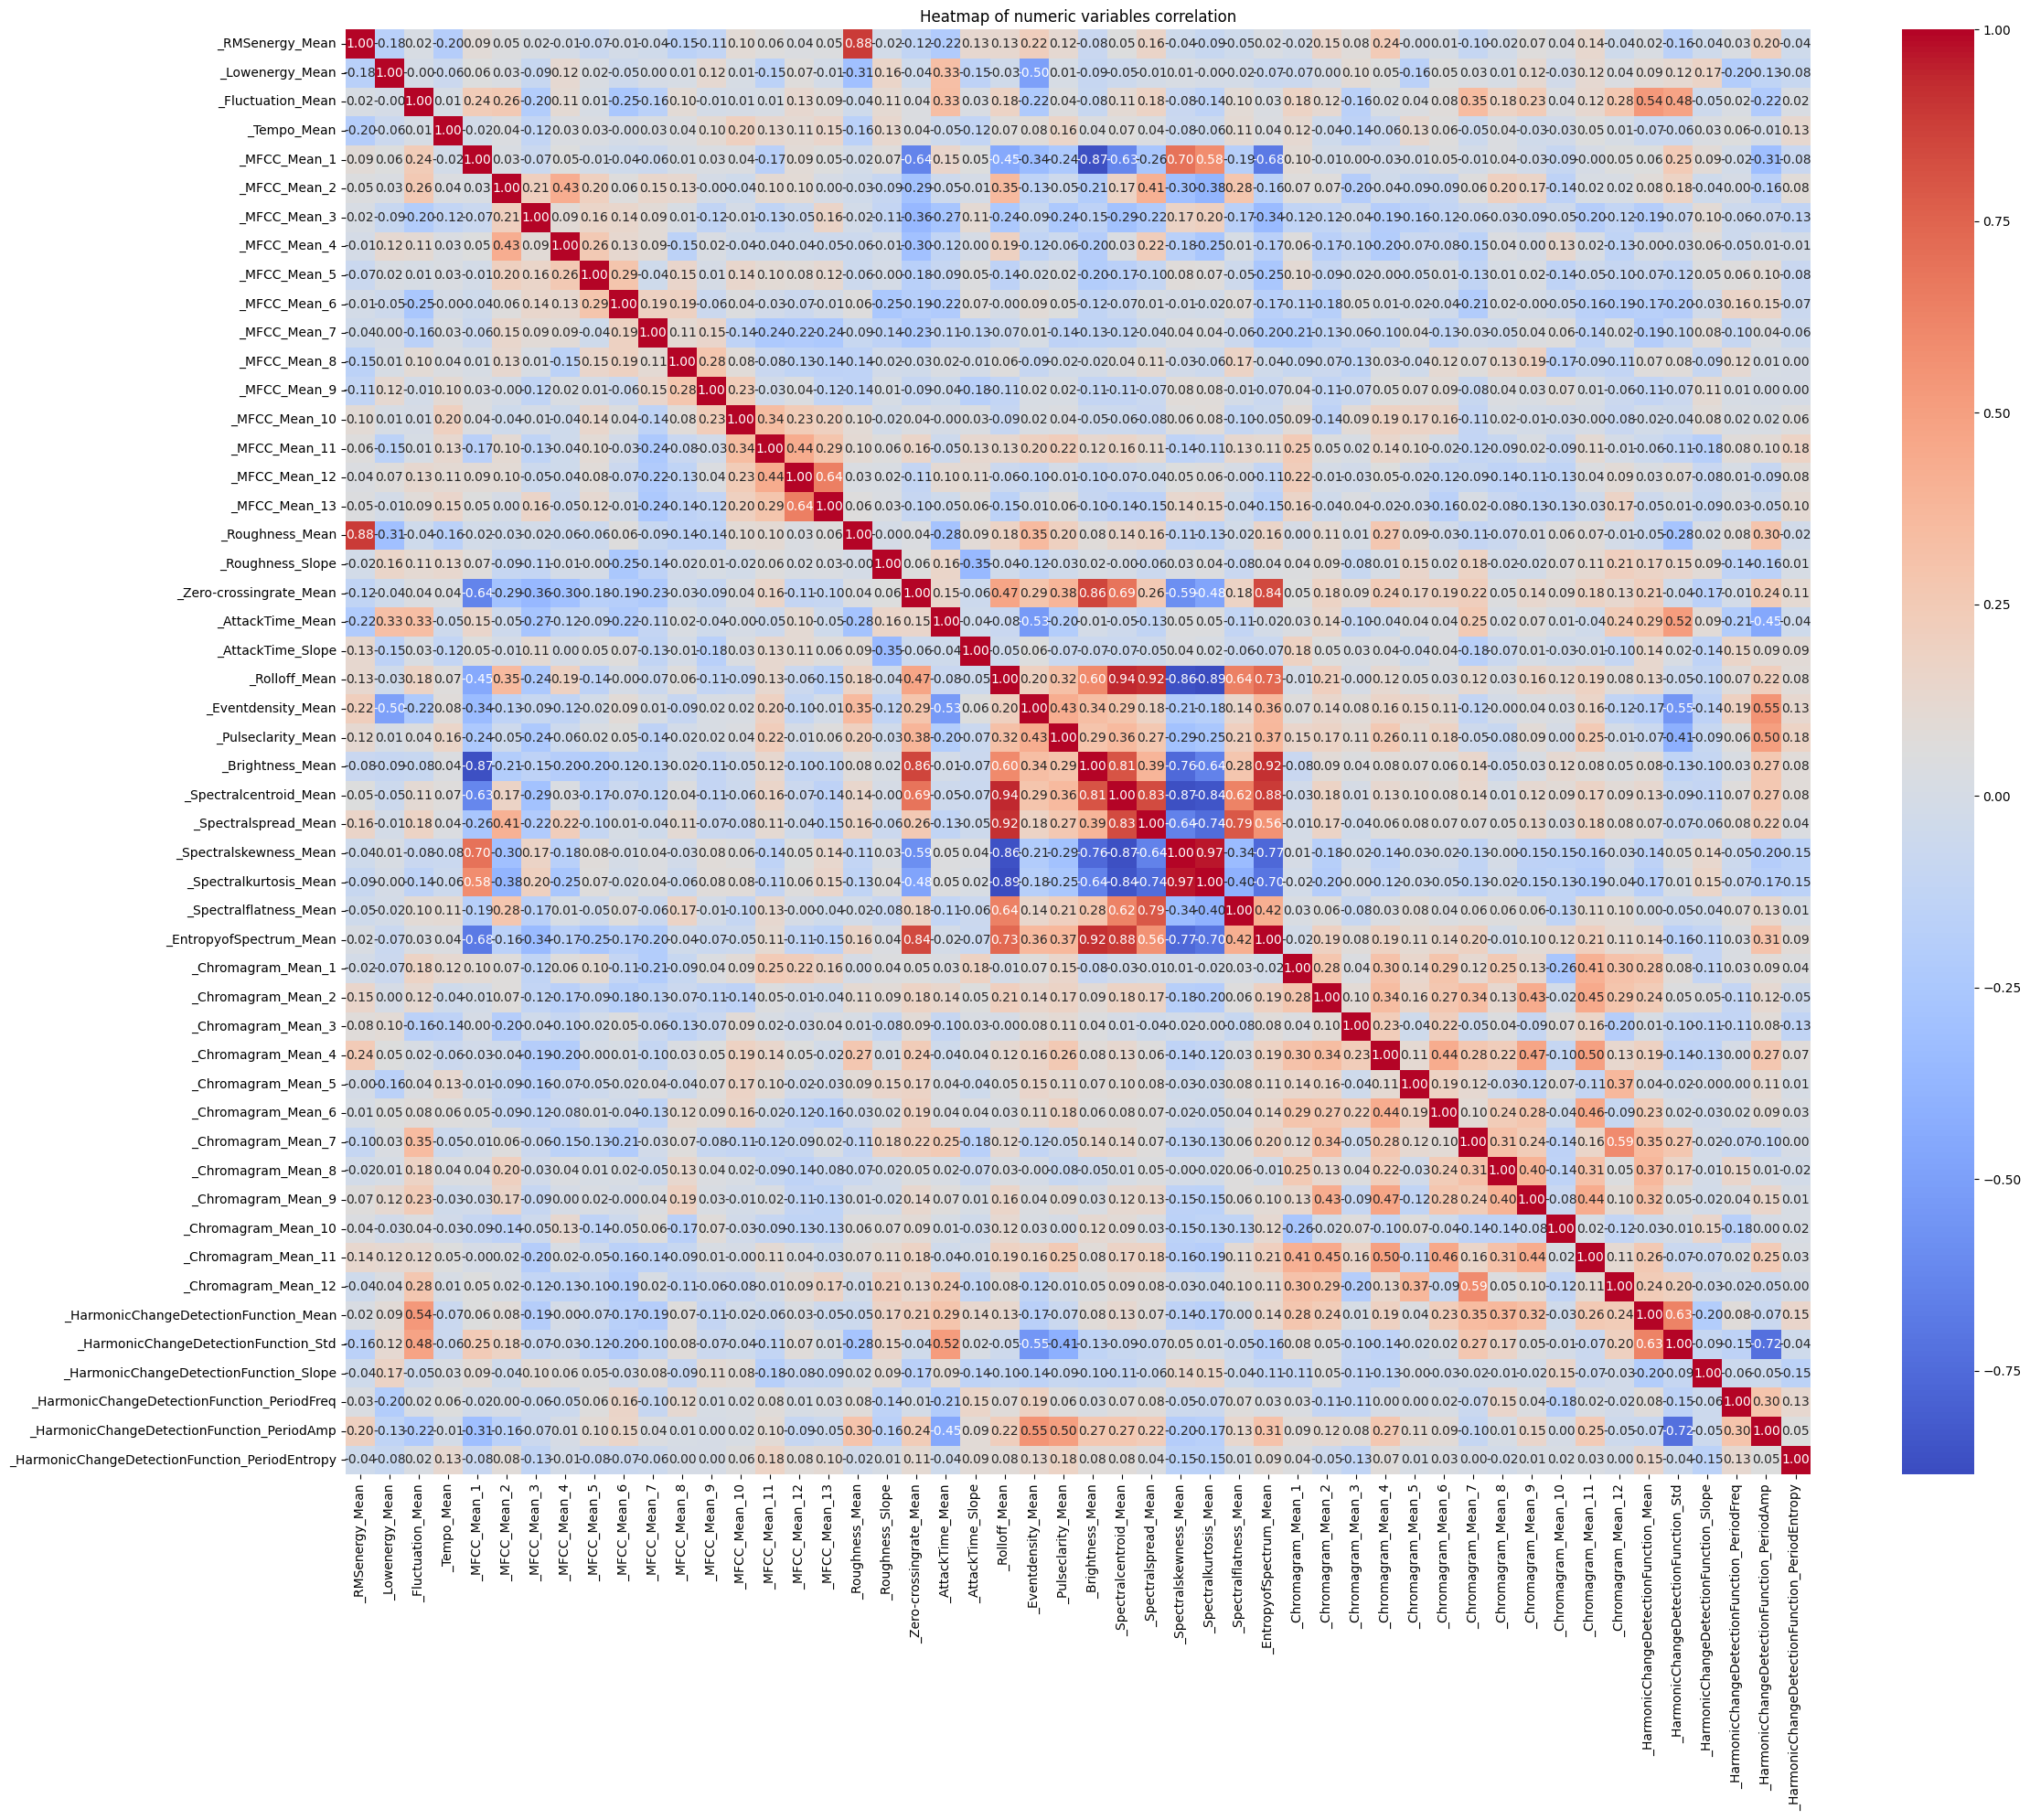

In [120]:
correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(24, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap of numeric variables correlation')
plt.tight_layout()
plt.show()


# **Transformations and data preparation**

## Data normalization

In [121]:
scaler = PowerTransformer(method='yeo-johnson')

df[numeric_columns] = scaler.fit_transform(df[numeric_columns])

In [122]:
df.head()

,Class,_RMSenergy_Mean,_Lowenergy_Mean,_Fluctuation_Mean,_Tempo_Mean,_MFCC_Mean_1,_MFCC_Mean_2,_MFCC_Mean_3,_MFCC_Mean_4,_MFCC_Mean_5,...,_Chromagram_Mean_9,_Chromagram_Mean_10,_Chromagram_Mean_11,_Chromagram_Mean_12,_HarmonicChangeDetectionFunction_Mean,_HarmonicChangeDetectionFunction_Std,_HarmonicChangeDetectionFunction_Slope,_HarmonicChangeDetectionFunction_PeriodFreq,_HarmonicChangeDetectionFunction_PeriodAmp,_HarmonicChangeDetectionFunction_PeriodEntropy
15,relax,0.671550,0.895436,1.079591,-2.001373,-0.052637,0.951989,1.622710,1.140017,2.140098,...,-0.879601,1.117071,-1.554711,-1.189938,-0.716953,0.397233,2.011488,-1.572311,-1.108687,-0.409430
16,relax,0.009538,-0.745064,0.490471,1.010864,-0.690802,1.382068,1.240743,1.362885,1.405832,...,-0.896495,0.196539,-1.502997,0.728464,0.635600,1.280820,-1.654401,1.049265,-0.832812,-0.041494
17,relax,-0.228621,0.457259,0.485601,-1.511469,0.699378,0.760034,0.327033,1.547231,0.197879,...,0.054708,-0.382318,-0.246876,1.438951,1.516756,1.120022,-1.360248,0.186686,-0.438369,-0.041494
23,relax,-0.265526,-0.109331,-0.414935,-1.748101,-1.135894,1.534186,2.153592,-0.580108,-0.181011,...,-0.140684,1.117071,-0.973049,1.058018,0.173746,1.280820,1.340816,-1.100173,-0.899903,-0.409430
28,relax,0.794249,1.061204,1.533347,-0.597765,0.109064,1.300214,0.424991,-0.126134,0.945933,...,1.605940,-0.511776,0.869952,-0.057919,1.336127,0.570934,0.886631,0.555334,-0.263926,0.341485


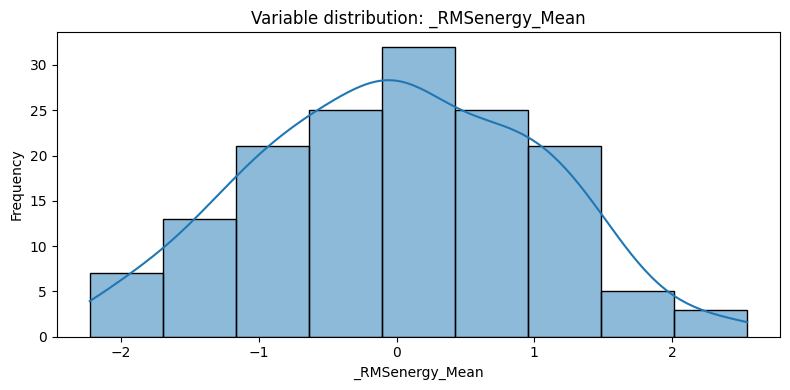

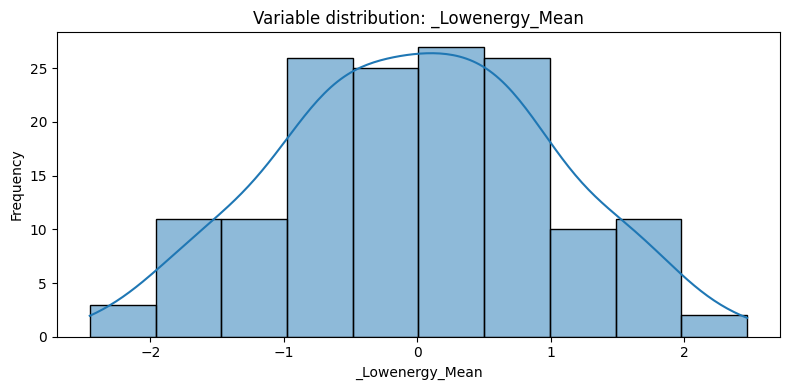

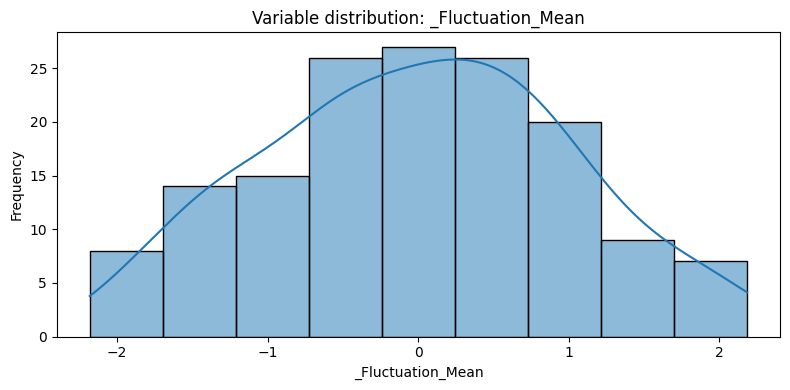

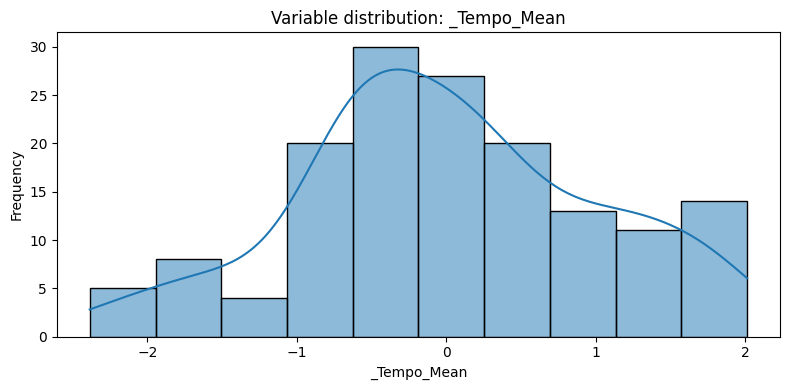

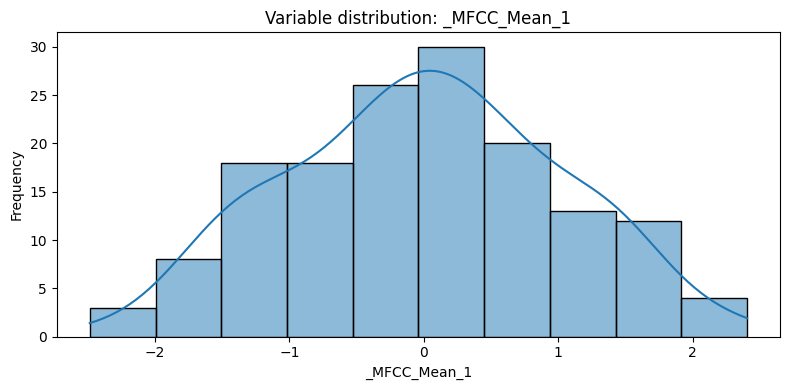

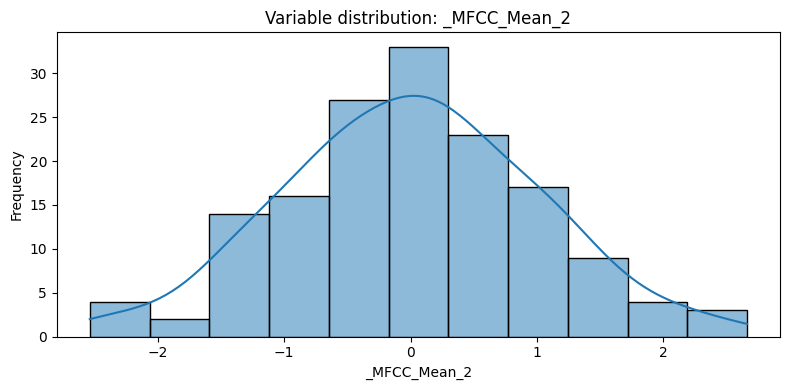

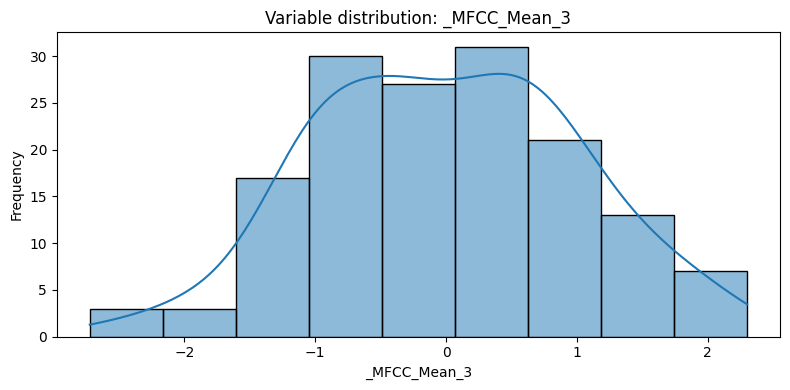

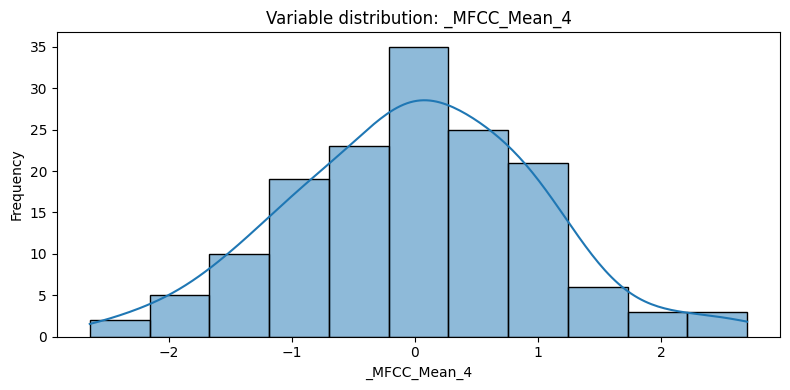

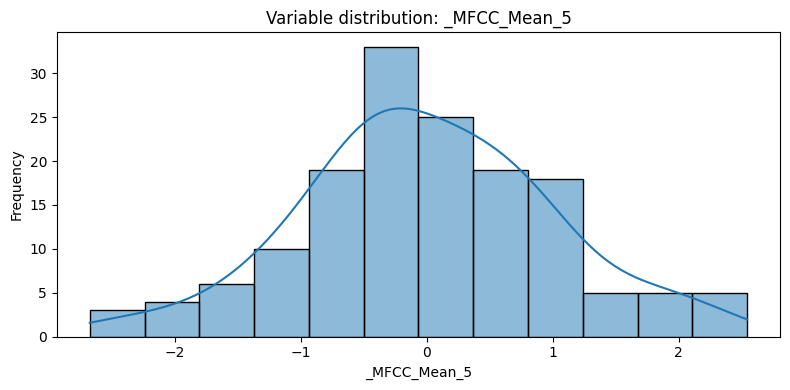

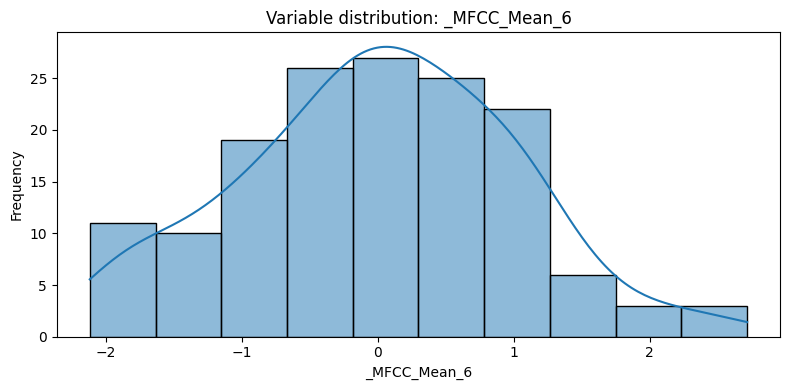

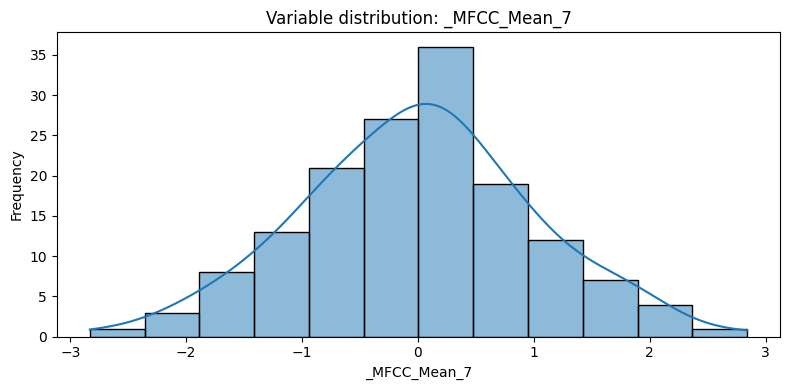

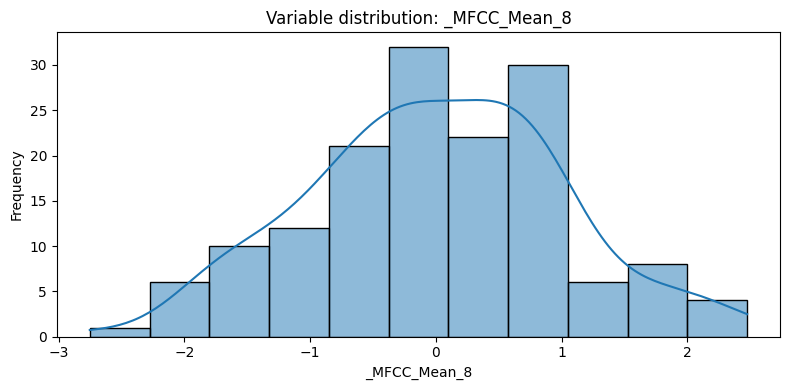

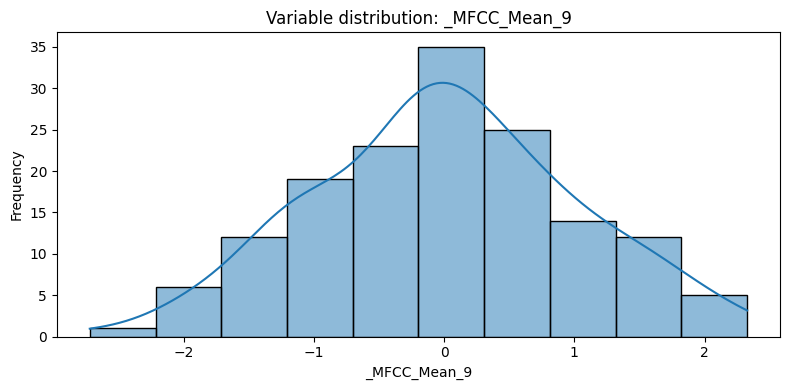

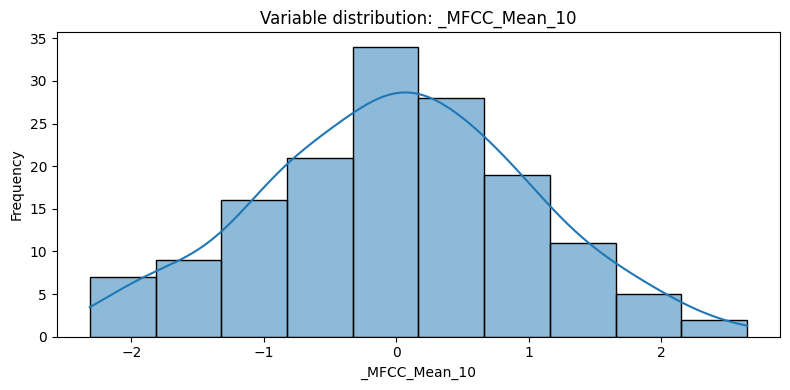

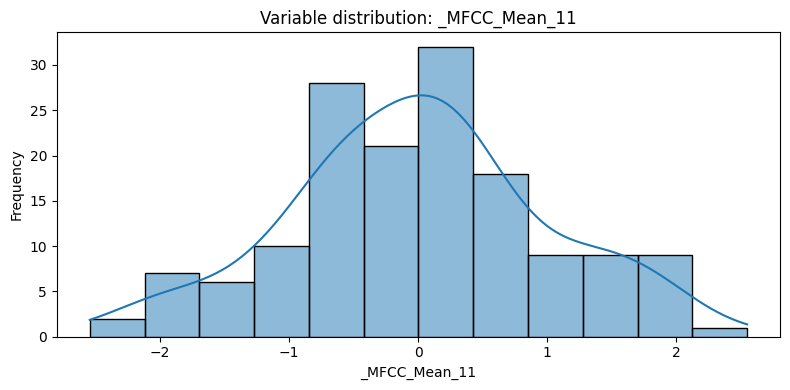

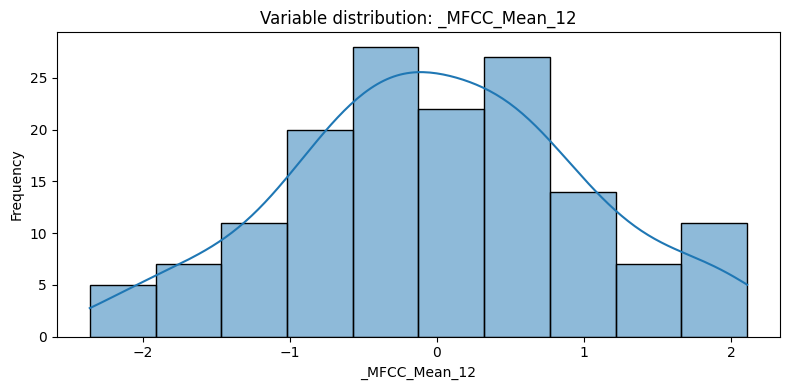

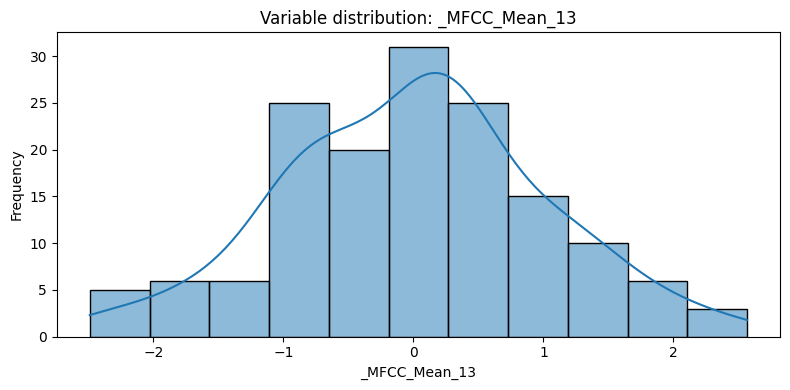

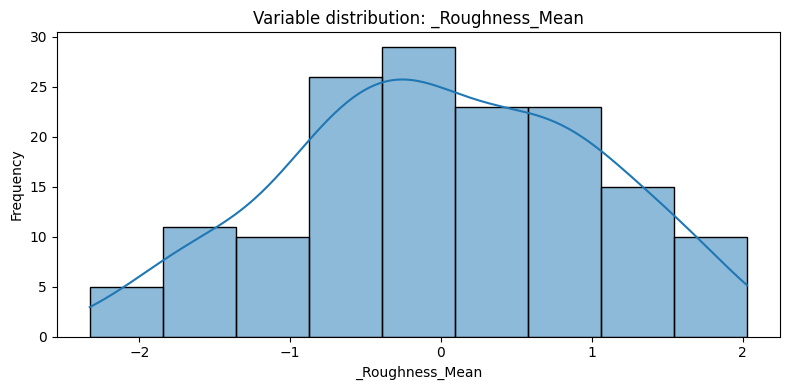

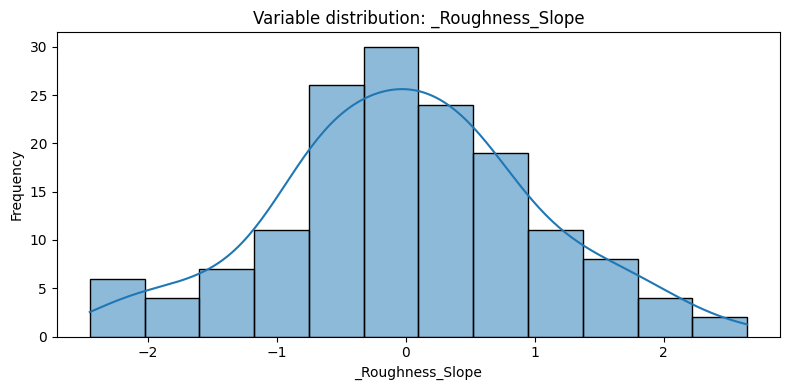

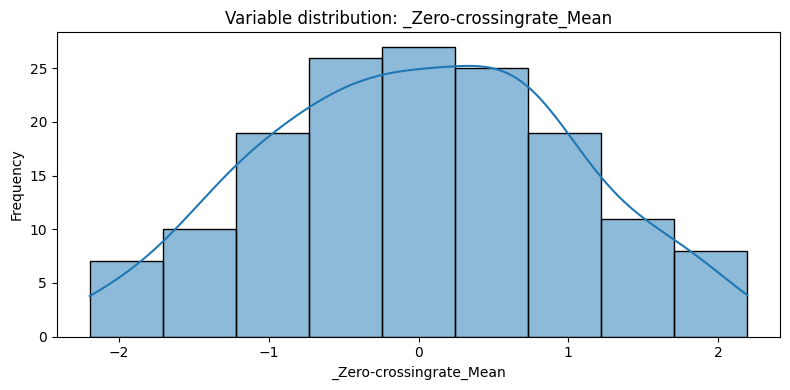

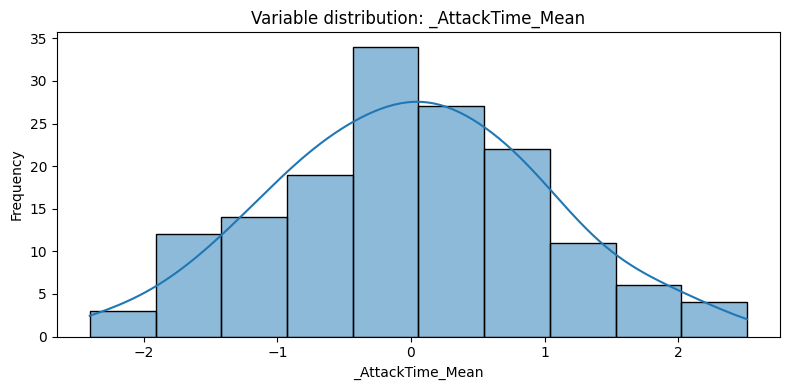

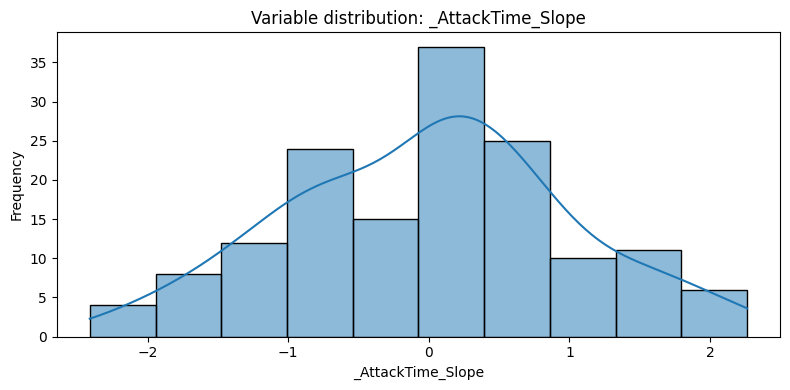

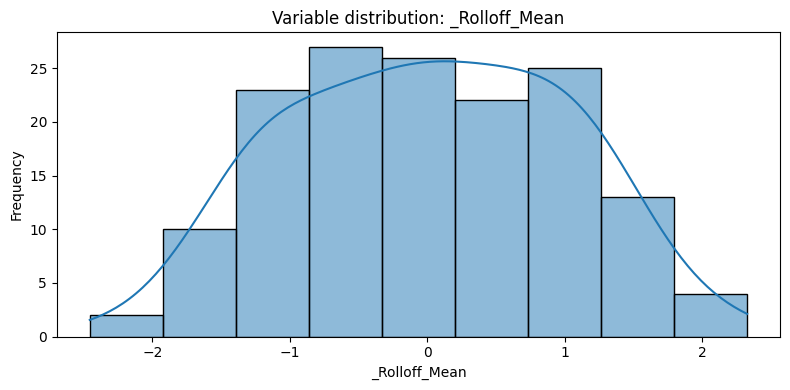

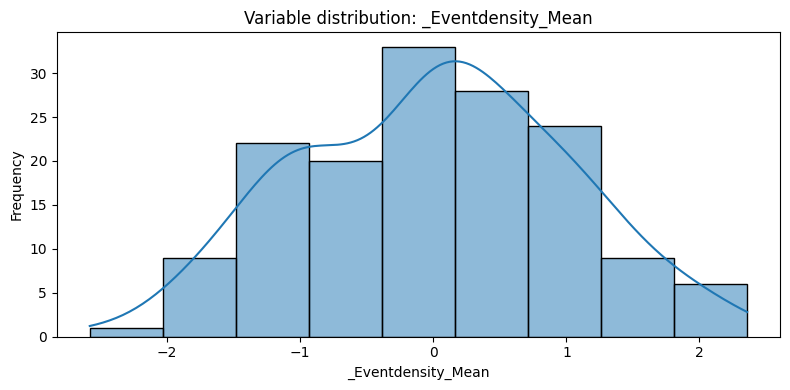

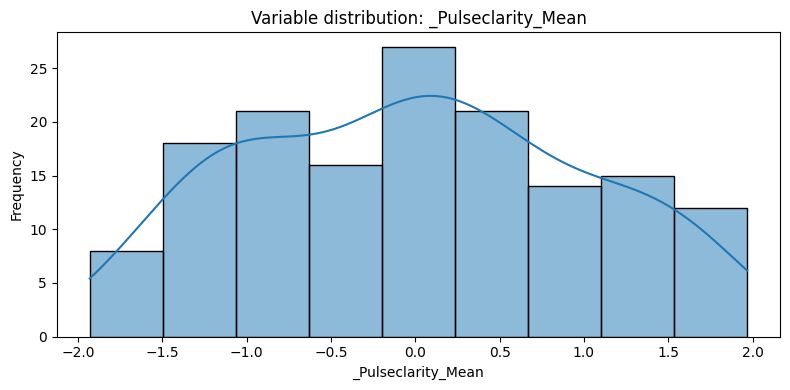

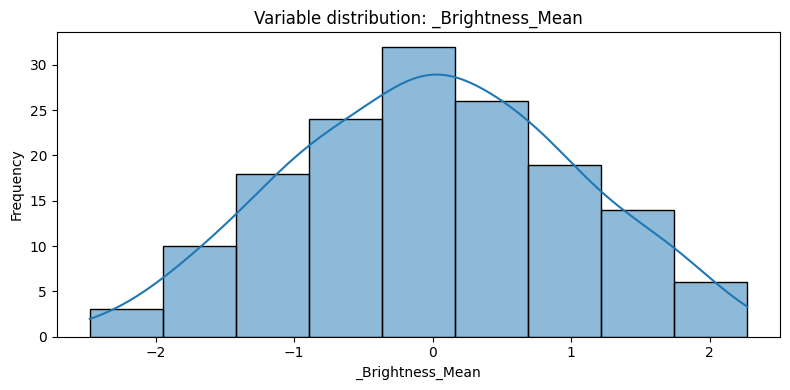

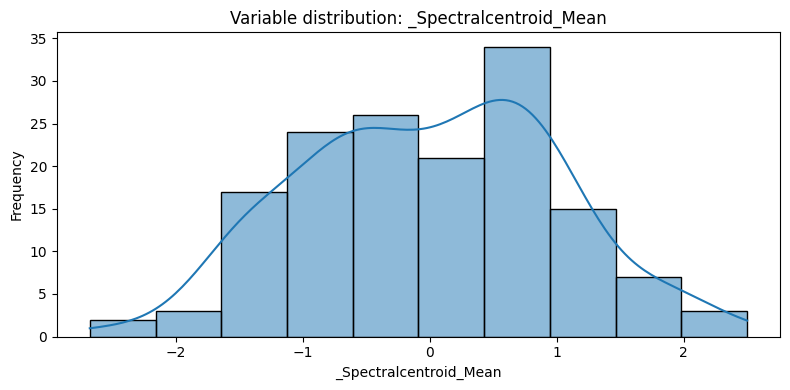

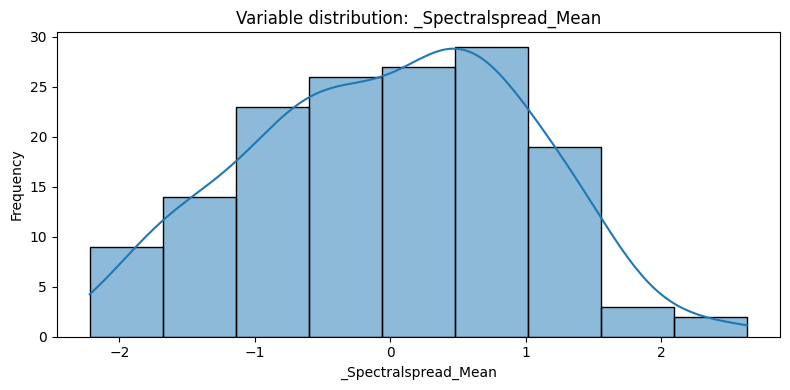

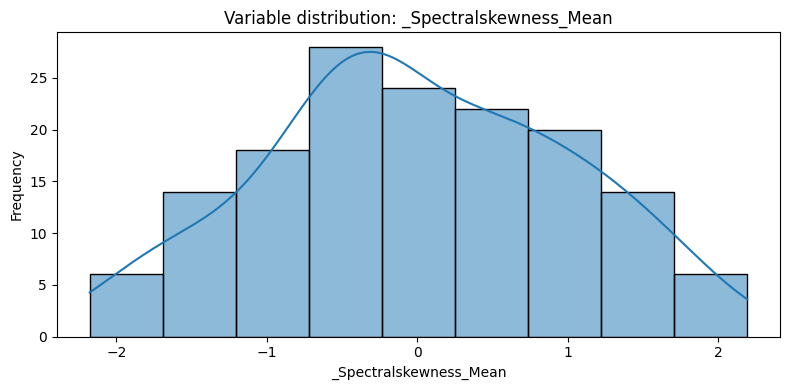

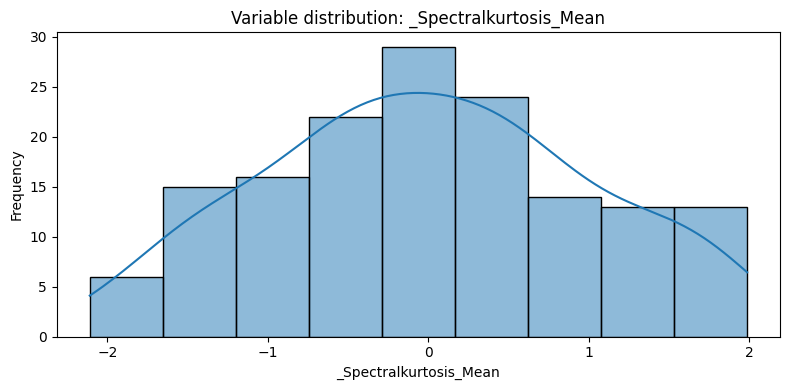

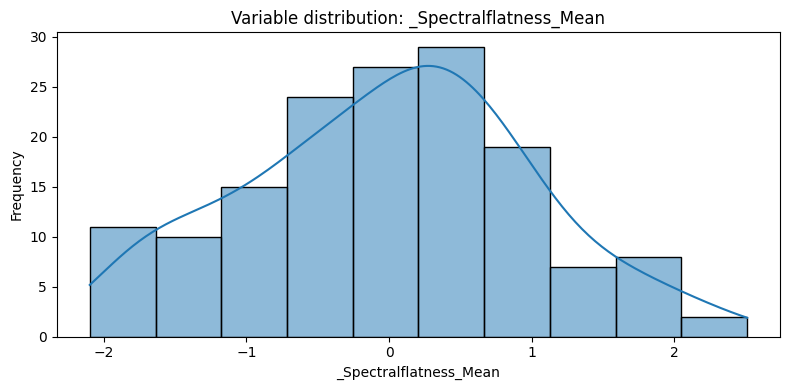

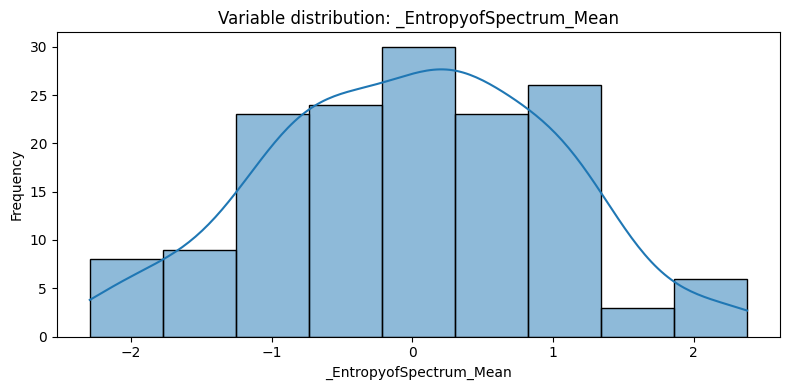

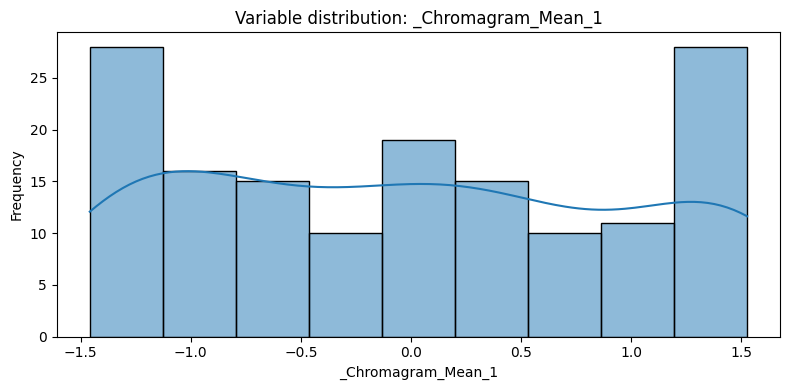

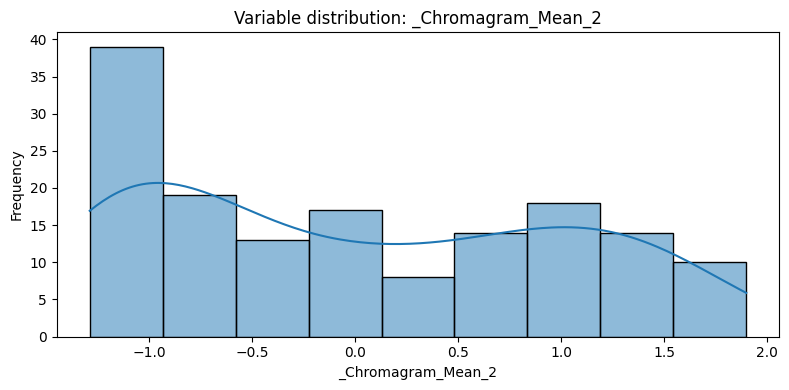

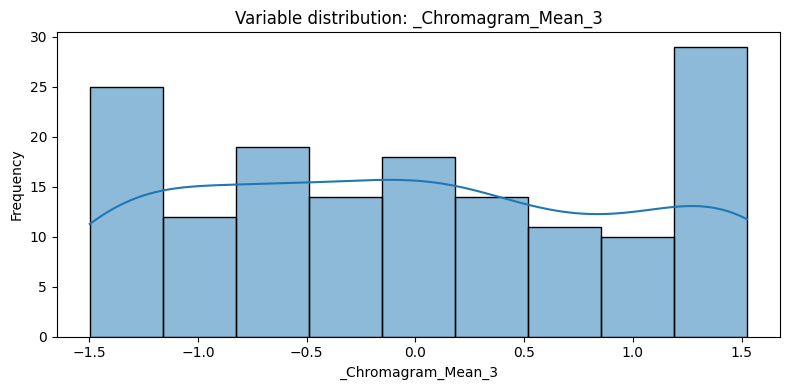

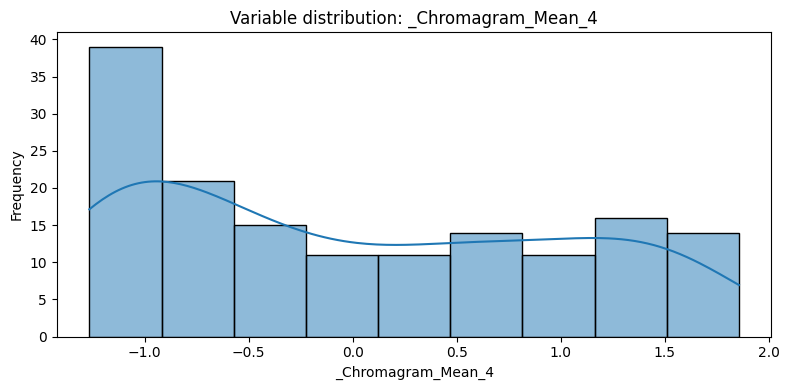

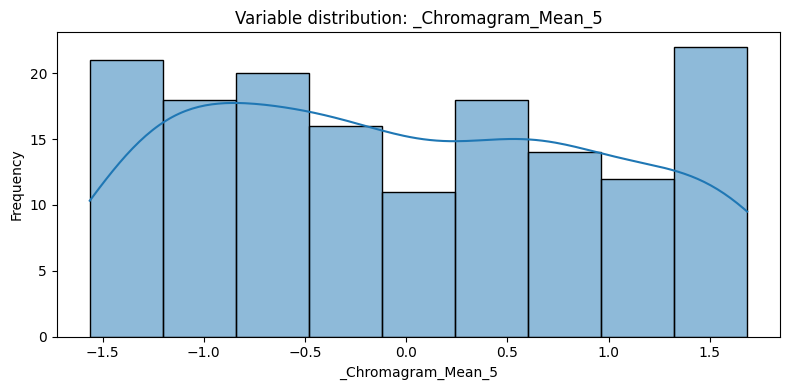

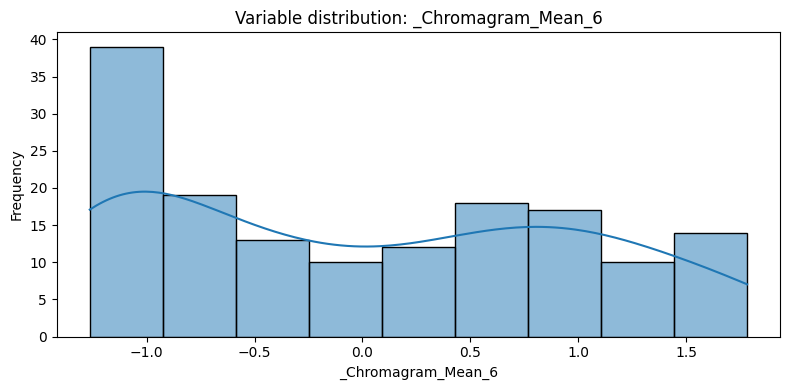

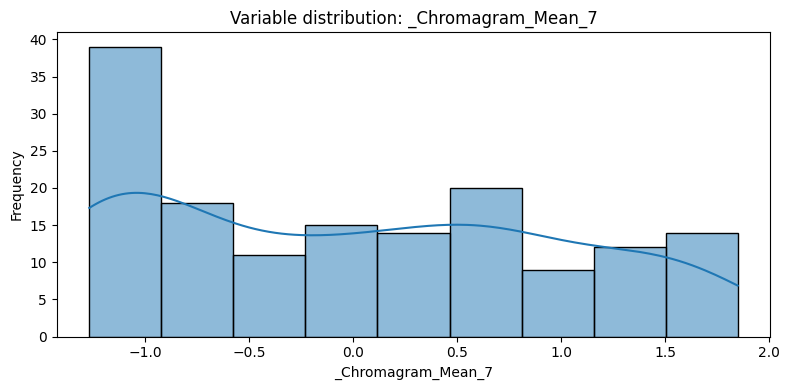

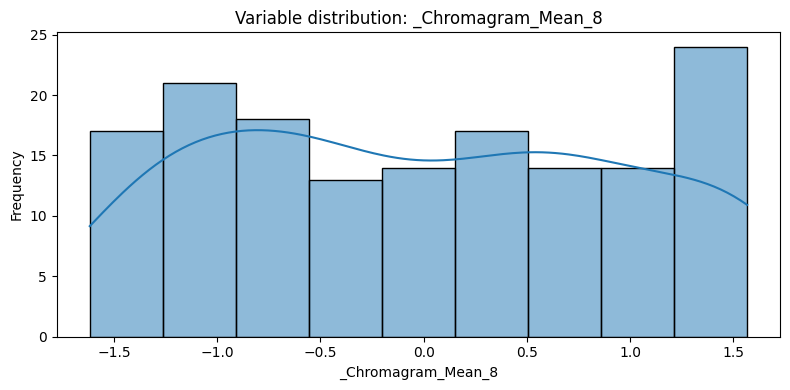

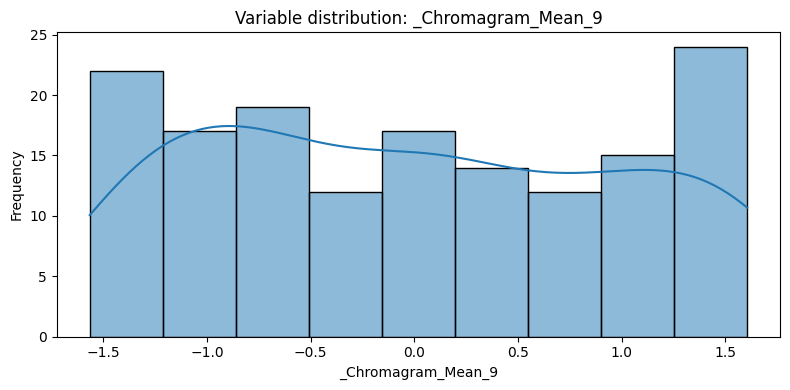

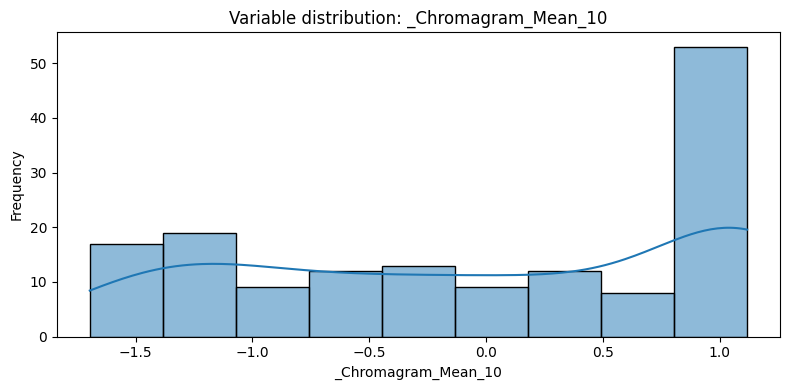

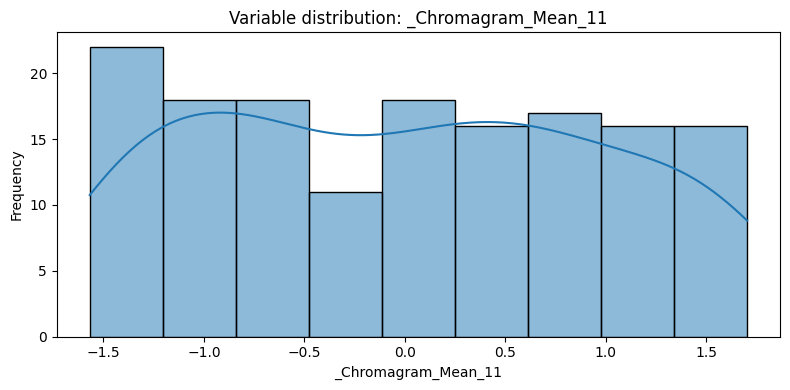

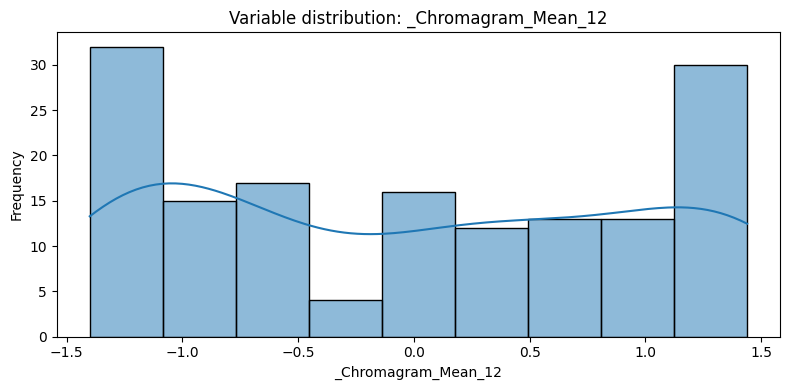

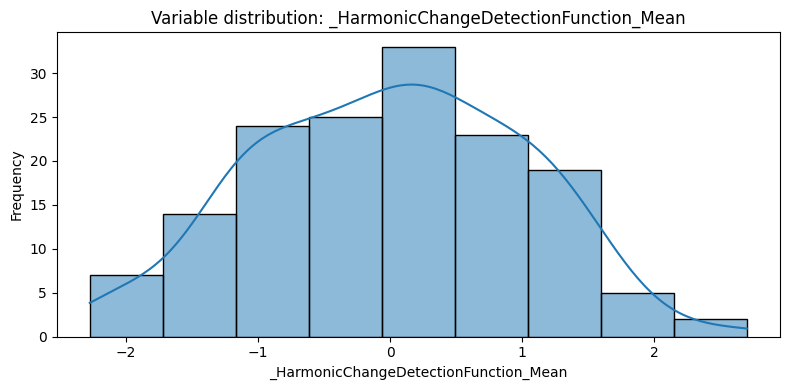

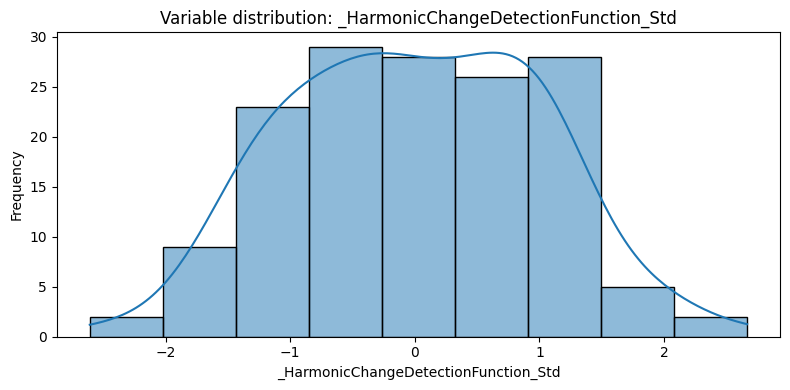

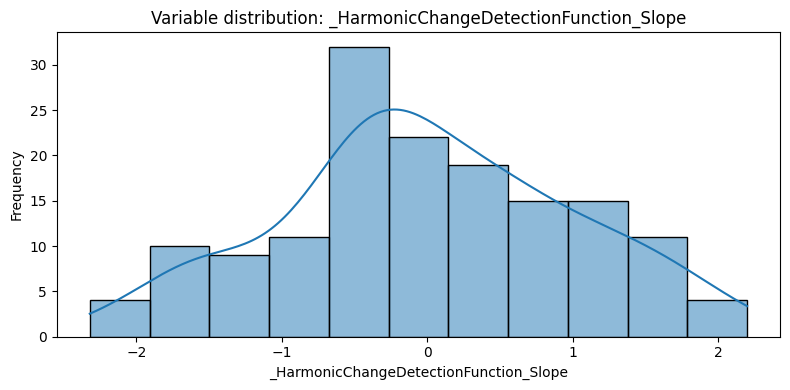

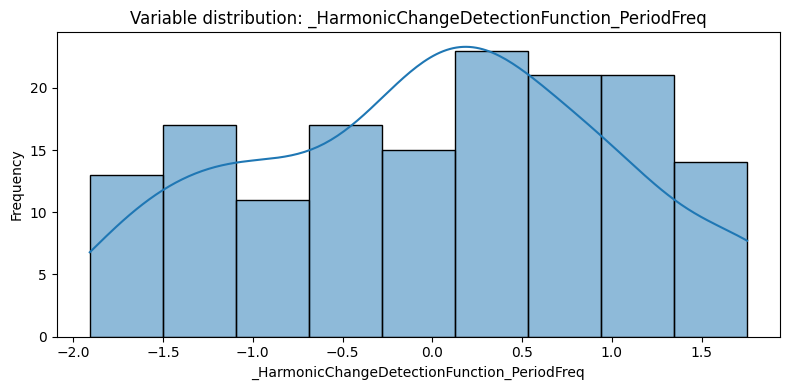

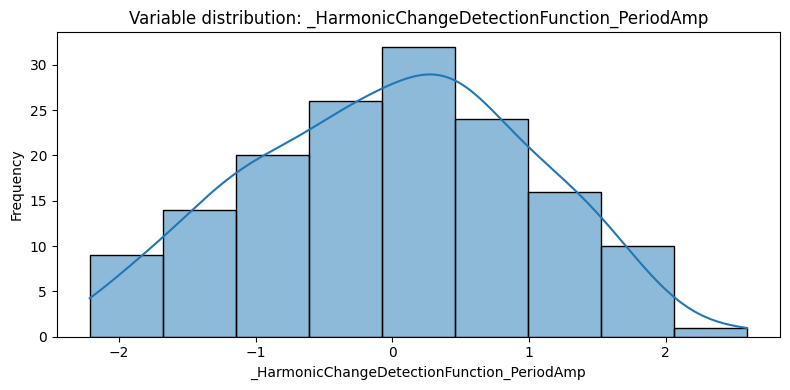

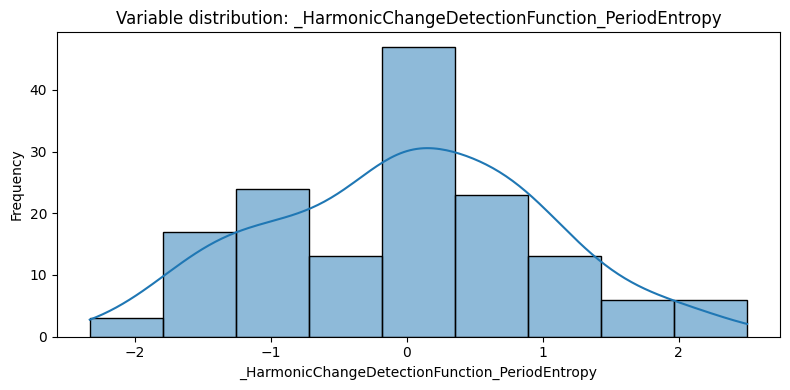

In [123]:
for col in numeric_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Variable distribution: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

## Dimensionality reduction

In [124]:
pca = PCA()
df_numeric = df[numeric_columns]
pca.fit(df_numeric)
explained_variance = pca.explained_variance_ratio_

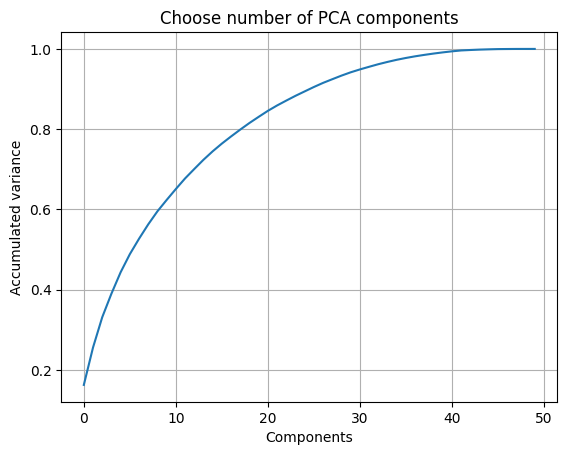

In [125]:
plt.plot(np.cumsum(explained_variance))
plt.xlabel('Components')
plt.ylabel('Accumulated variance')
plt.title('Choose number of PCA components')
plt.grid(True)
plt.show()

## Split dataset

In [128]:
train_df, temp_df = train_test_split(df, test_size=0.4, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

In [131]:
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)

In [132]:
files.download('train.csv')
files.download('val.csv')
files.download('test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>